In [21]:
# ============================================================
# 📦 CORE LIBRARIES & ENVIRONMENT SETUP
# ============================================================

# --- Core Python ---
import os
import re
import warnings
warnings.filterwarnings("ignore")  # Suppress warnings for cleaner output

# --- Numerical & Data Analysis ---
import numpy as np
import pandas as pd

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal Processing ---
from scipy.signal import (
    butter, filtfilt, resample, resample_poly, find_peaks
)

# --- Statistics ---
from scipy.stats import (
    wilcoxon, ttest_rel, ttest_ind, spearmanr, pearsonr, zscore
)

# --- Machine Learning (for logistic regression / modeling) ---
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
)

# --- Specialized Neuroscience Tools ---
import neurokit2 as nk

# --- Optional: Display Settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)

# --- Optional: Plotting Style ---
sns.set(style="whitegrid", context="talk", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("✅ All libraries successfully loaded and environment initialized.")



✅ All libraries successfully loaded and environment initialized.


In [22]:
# --- Respiration file paths (.h5) --- # Baseline recordings
resp_paths_bl = {
    "BL_1_1_d1_2": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_1_d1_2_20250623_103713_merged.h5",
    "BL_1_2_sub1_1": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s1_2_sub_1_1_20250623_120135_merged.h5",
    "BL_2_3_d2_4": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_3_d2_4_20250623_145448_merged.h5",
    "BL_2_4_sub2_3": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s2_4_sub2_3_20250623_141419_merged.h5",
    "BL_3_5_d3_6": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_5_d3_6_20250623_154154_merged.h5",
    "BL_3_6_sub3_5": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s3_6_sub3_5_20250623_172635_merged.h5",
    "BL_4_7_d4_8": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_7_d4_8_20250623_185042_merged.h5",
    "BL_4_8_sub4_7": r"E:\Aim1\AIM1\Cagemate_bl_no_ISO\h5_outputs\BL_s4_8_sub4_7_20250623_180810_merged.h5"
}
resp_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_2_sub1_1_20250623_133932_merged.h5",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_3_d2_4_20250623_151153_merged.h5",
    "CM_2_4_sub2_2": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s2_4_sub2_3_20250623_143348_merged.h5",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_5_d3_6_20250623_170708_merged.h5",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s3_6_sub3_5_20250623_174348_merged.h5",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_7_d4_8_20250623_193718_merged.h5",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s4_8_sub4_7_20250623_182649_merged.h5",
# 1 day post isolation recordings
    "CM_1_1_d1_2_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s1_1_d1_2_1d_iso_20250625_162417_merged.h5",
    "CM_1_2_sub1_1_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s1_2_sub1_1_1d_iso_20250625_154217_merged.h5",
    "CM_2_3_d2_4_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s2_3_d2_4_1d_iso_20250625_131108_merged.h5",
    "CM_2_4_sub2_3_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s2_4_sub2_3_1d_iso_20250625_135245_merged.h5",
    "CM_3_5_d3_6_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s3_5_d3_6_1d_ios_20250625_122928_merged.h5",
    "CM_3_6_sub3_5_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s3_6_sub3_5_1d_iso_20250625_115503_merged.h5",
    "CM_4_7_d4_8_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s4_7_d4_8_1d_iso_20250625_103352_merged.h5",
    "CM_4_8_sub4_7_1d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\1d_iso_h5\cagemate_day_1_h5_outputs\CM_s4_8_sub4_7_1d_iso_20250625_111037_merged.h5",
# 10 day post isolation recordings
    "CM_1_1_d1_2_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s1_2_d1_1_10d_iso_20250704_174528_merged.h5", #miss named file during recording this is 1.1 not 1.2 
    "CM_1_2_sub1_1_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s1_2_sub1_1_10d_iso_real_1_2_20250704_182224_merged.h5",
    "CM_2_3_d2_4_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s2_3_d2_4_10d_iso_20250704_170242_merged.h5",
    "CM_2_4_sub2_3_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s2_4_sub2_3_10d_iso_20250704_162648_merged.h5",
    "CM_3_5_d3_6_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s3_5_d3_6_10d_iso_20250704_151236_merged.h5",
    "CM_3_6_sub3_5_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s3_6_sub3_5_10d_iso_20250704_154606_merged.h5",
    "CM_4_7_d4_8_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s4_7_d4_8_10d_iso_20250704_143622_merged.h5",
    "CM_4_8_sub4_7_10d": r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\10d_iso_h5\cagemate_day_10_h5_outputs\CM_s4_8_sub4_7_10d_iso_20250704_135738_merged.h5"

}

# --- BORIS annotation file paths (.csv) --- # Baseline recordings
boris_paths_cm = {
    "CM_1_1_d1_2": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_1_d1_2_20250623_111352.1.csv",
    "CM_1_2_sub1_1": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s1_2_sub1_1_20250623_133932.1_VT.csv",
    "CM_2_3_d2_4": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_3_d2_4_20250623_151153.1.csv",
    "CM_2_4_sub2_3": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s2_4_sub2_3_20250623_143348.1_VT.csv",
    "CM_3_5_d3_6": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_5_d3_6_20250623_160001.csv",
    "CM_3_6_sub3_5": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s3_6_sub3_5_20250623_174348.csv",
    "CM_4_7_d4_8": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_7_d4_8_20250623_193718.csv",
    "CM_4_8_sub4_7": r"E:\Aim1\AIM1\Day1_new\cm_boris\baseline csv\CM_s4_8_sub4_7_20250623_182649.1_VT.csv",
}

print(f"✅ Resp files: {len(resp_paths_cm)} trials")
print(f"✅ Resp files: {len(resp_paths_bl)} trials")
print(f"✅ BORIS files: {len(boris_paths_cm)} trials")

✅ Resp files: 24 trials
✅ Resp files: 8 trials
✅ BORIS files: 8 trials


In [23]:
# --- Respiration file paths (.h5) ---
resp_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_1_p5_2_nRB6_20250622_143958_merged.h5",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_1_p5_2_nRB6_20250622_150457_merged.h5",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s1_2_p5_1_nRB6_20250622_170742_merged.h5",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s1_2_p5_1_nRB6_20250622_173049_merged.h5",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_4_p5_4_nRB3_20250622_123424_merged.h5",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_4_p5_4_nRB3_20250622_125648_merged.h5",
    "RI1_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_5_p5_4_nRB3_20250621_105014_merged.h5",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_5_p5_4_nRB3_20250621_112618_merged.h5",
    # Baseline recordings
    "BLRI_1_1": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_1_p5_2_nRB6_20250622_141846_merged.h5",
    "BLRI_1_2": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s1_2_p5_1_nRB6_20250622_164833_merged.h5",
    "BLRI_2_3": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_3_p5_3_nRB3_20250622_101813_merged.h5",
    "BLRI_2_4": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s2_4_p5_4_nRB3_20250622_121708_merged.h5",
    "BLRI_3_6": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5",
    "BLRI_4_7": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5",
    "BLRI_4_8": r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_8_p5_1_nRB3_20250621_163506_merged.h5",
}

# --- BORIS annotation file paths (.csv) ---
boris_paths = {
    "RI1_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv",
    "RI2_3_6": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv",
    "RI1_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI2_4_7": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv",
    "RI1_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv",
    "RI2_2_3": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv",
    "RI1_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv",
    "RI2_4_8": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv",
    "RI1_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_1_p5_2_nRB6_20250622_143958.1.csv",
    "RI2_1_1": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_1_p5_2_nRB6_20250622_150457.1.csv",
    "RI1_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s1_2_p5_1_nRB6_20250622_170742.1.csv",
    "RI2_1_2": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s1_2_p5_1_nRB6_20250622_173049.1.csv",
    "RI1_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_4_p5_4_nRB3_20250622_123424.1.csv",
    "RI2_2_4": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_4_p5_4_nRB3_20250622_125648.1.csv",
    "RI2_3_5": r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_5_p5_4_nRB3_20250621.csv",
}

print(f"✅ Resp files: {len(resp_paths)} trials")
print(f"✅ BORIS files: {len(boris_paths)} trials")

✅ Resp files: 23 trials
✅ BORIS files: 15 trials


In [24]:
# --- Load BORIS CSVs into DataFrames (auto from boris_paths) ---
boris_data = {}

for label, path in boris_paths_cm.items():
    try:
        df = pd.read_csv(path)
        boris_data[label] = df.copy()
        print(f"Loaded BORIS: {label} ({df.shape[0]} rows)")
    except Exception as e:
        print(f"❌ Error loading {label}: {e}")

print(f"✅ Loaded {len(boris_data)} BORIS files")

Loaded BORIS: CM_1_1_d1_2 (129 rows)
Loaded BORIS: CM_1_2_sub1_1 (41 rows)
Loaded BORIS: CM_2_3_d2_4 (97 rows)
Loaded BORIS: CM_2_4_sub2_3 (75 rows)
Loaded BORIS: CM_3_5_d3_6 (90 rows)
Loaded BORIS: CM_3_6_sub3_5 (0 rows)
Loaded BORIS: CM_4_7_d4_8 (49 rows)
Loaded BORIS: CM_4_8_sub4_7 (70 rows)
✅ Loaded 8 BORIS files


In [25]:
import h5py

test_file = r"E:\Aim1\AIM1\Day1_new\resp_CM_h5\baseline_cagemate_interactions_h5_outputs\CM_s1_1_d1_2_20250623_111352_merged.h5"

with h5py.File(test_file, 'r') as f:
    print("\n--- resp_metadata attrs ---")
    for k, v in f['resp_metadata'].attrs.items():
        print(f"{k}: {v}")



--- resp_metadata attrs ---
byte_order: little endian
channel: analog_ECU_Ain1
duration_sec: 612.6156
duration_sec_from_ekg_sr: 612.6156
duration_sec_hardcoded_20k: 612.6156
num_samples: 12252312
sampling_frequency: 20000.0
start_time: nan
units: volts


In [26]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Load respiration from .h5, resample to target_rate, band-pass clean.
    Returns: (resp_signal, time_vector, sampling_rate)
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()

            # Grab metadata from resp_metadata
            meta = dict(f['resp_metadata'].attrs)
            duration_sec = float(meta.get('duration_sec'))
            fs = float(meta.get('sampling_frequency'))

        # safety check
        if fs <= 0:
            raise ValueError("Invalid sampling frequency in metadata")

    except Exception as e:
        print(f"❌ Error loading {h5_file}: {e}")
        return None, None, None

    # --- Low-pass filter to remove noise ---
    cutoff_hz = min(0.45 * fs, 20.0) if target_rate >= fs else target_rate / 2.0
    Wn = cutoff_hz / (fs / 2.0)
    b, a = butter(N=4, Wn=Wn, btype='low')
    filtered = filtfilt(b, a, resp)

    # --- Resample to EXACT target_rate ---
    N_out = int(round(duration_sec * target_rate))
    resampled = resample(filtered, N_out)

    # --- Final band-pass clean (0.1–15 Hz) ---
    rsp_cleaned = nk.signal_filter(
        resampled, lowcut=0.1, highcut=15.0,
        method="butterworth", sampling_rate=target_rate, order=2
    )

    time_vector = np.arange(len(rsp_cleaned)) / float(target_rate)
    return rsp_cleaned, time_vector, float(target_rate)



In [16]:
# --- Load all respiration files into a dictionary ---
resp_data = {}

for label, path in resp_paths_cm.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
        print(f"✅ Loaded {label}: {len(signal)} samples, duration={time[-1]:.1f}s, fs={rate} Hz")
    else:
        print(f"❌ Skipped {label} (failed to load)")

print(f"\n✅ Finished: {len(resp_data)} respiration traces loaded")


Processing CM_1_1_d1_2...
✅ Loaded CM_1_1_d1_2: 61262 samples, duration=612.6s, fs=100.0 Hz
Processing CM_1_2_sub1_1...
✅ Loaded CM_1_2_sub1_1: 60566 samples, duration=605.6s, fs=100.0 Hz
Processing CM_2_3_d2_4...
✅ Loaded CM_2_3_d2_4: 61143 samples, duration=611.4s, fs=100.0 Hz
Processing CM_2_4_sub2_2...
✅ Loaded CM_2_4_sub2_2: 62196 samples, duration=622.0s, fs=100.0 Hz
Processing CM_3_5_d3_6...
✅ Loaded CM_3_5_d3_6: 60594 samples, duration=605.9s, fs=100.0 Hz
Processing CM_3_6_sub3_5...
✅ Loaded CM_3_6_sub3_5: 60426 samples, duration=604.2s, fs=100.0 Hz
Processing CM_4_7_d4_8...
✅ Loaded CM_4_7_d4_8: 60319 samples, duration=603.2s, fs=100.0 Hz
Processing CM_4_8_sub4_7...
✅ Loaded CM_4_8_sub4_7: 60508 samples, duration=605.1s, fs=100.0 Hz
Processing CM_1_1_d1_2_1d...
✅ Loaded CM_1_1_d1_2_1d: 60229 samples, duration=602.3s, fs=100.0 Hz
Processing CM_1_2_sub1_1_1d...
✅ Loaded CM_1_2_sub1_1_1d: 61924 samples, duration=619.2s, fs=100.0 Hz
Processing CM_2_3_d2_4_1d...
✅ Loaded CM_2_3_d2_

In [ ]:
# --- Standardize behavior + subject labels in BORIS ---
def clean_boris(df, trial_name):
    df = df.copy()

    # Ensure Behavior + Subject columns exist
    if "Behavior" not in df.columns or "Subject" not in df.columns:
        print(f"⚠️ Skipping {trial_name}: Missing Behavior or Subject column")
        return df

    # Normalize text
    df['Behavior'] = df['Behavior'].astype(str).str.strip().str.lower()
    df['Subject'] = df['Subject'].astype(str).str.strip().str.lower()

    # Map behaviors to consistent labels
    behavior_label_map = {
        "facial sniffing": "Facial Sniffing",
        "body sniffing": "Body Sniffing",
        "anogenital sniffing": "Anogenital Sniffing",
        "fighting": "Fighting",
        "chasing": "Chasing",
        "tail rattling": "Tail Rattling",
        "posturing": "Posturing"
    }
    df['Behavior'] = df['Behavior'].map(behavior_label_map).fillna(
        df['Behavior'].str.title()
    )

    # Standardize Subject column
    subject_label_map = {
        "subject": "Subject",
        "social_agent": "Social Agent",
        "agent": "Social Agent",
        "intruder": "Social Agent"
    }
    df['Subject'] = df['Subject'].map(subject_label_map).fillna(df['Subject'].str.title())

    # --- Parse rank from trial_name ---
    subj_id, agent_id, subj_rank, agent_rank = None, None, "Unknown", "Unknown"

    # Case: agent is dominant
    match_dom = re.search(r"CM_(\d+_\d+)_d(\d+_\d+)", trial_name)
    if match_dom:
        subj_id, agent_id = match_dom.group(1), match_dom.group(2)
        subj_rank, agent_rank = "Subordinate", "Dominant"

    # Case: agent is subordinate
    match_sub = re.search(r"CM_(\d+_\d+)_sub(\d+_\d+)", trial_name)
    if match_sub:
        subj_id, agent_id = match_sub.group(1), match_sub.group(2)
        subj_rank, agent_rank = "Dominant", "Subordinate"

    # Assign Rank column
    def assign_rank(row):
        if row["Subject"] == "Subject":
            return subj_rank
        elif row["Subject"] == "Social Agent":
            return agent_rank
        return "Unknown"

    df["Rank"] = df.apply(assign_rank, axis=1)
    df["Subject_ID"] = subj_id if subj_id else "Unknown"
    df["Agent_ID"] = agent_id if agent_id else "Unknown"

    return df


# --- Apply cleaning to all BORIS files ---
for key in boris_data:
    boris_data[key] = clean_boris(boris_data[key], key)
    print(f"✅ Cleaned BORIS labels + rank info for {key}")


✅ Cleaned BORIS labels + rank info for CM_1_1_d1_2
✅ Cleaned BORIS labels + rank info for CM_1_2_sub1_1
✅ Cleaned BORIS labels + rank info for CM_2_3_d2_4
✅ Cleaned BORIS labels + rank info for CM_3_5_d3_6
✅ Cleaned BORIS labels + rank info for CM_3_6_sub3_5
✅ Cleaned BORIS labels + rank info for CM_4_7_d4_8
⚠️ Skipping CM_4_8_sub4_7: Missing Behavior or Subject column
✅ Cleaned BORIS labels + rank info for CM_4_8_sub4_7


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\2549150816.py:29: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_bouts = pd.concat(all_bouts, ignore_index=True)


✅ Subjects with fixed rank mapping:
    Subject_ID         Rank
0          1_1  Subordinate
129        1_2     Dominant
163        2_3  Subordinate
260        3_5  Subordinate
350        4_7  Subordinate
399        4_8     Dominant


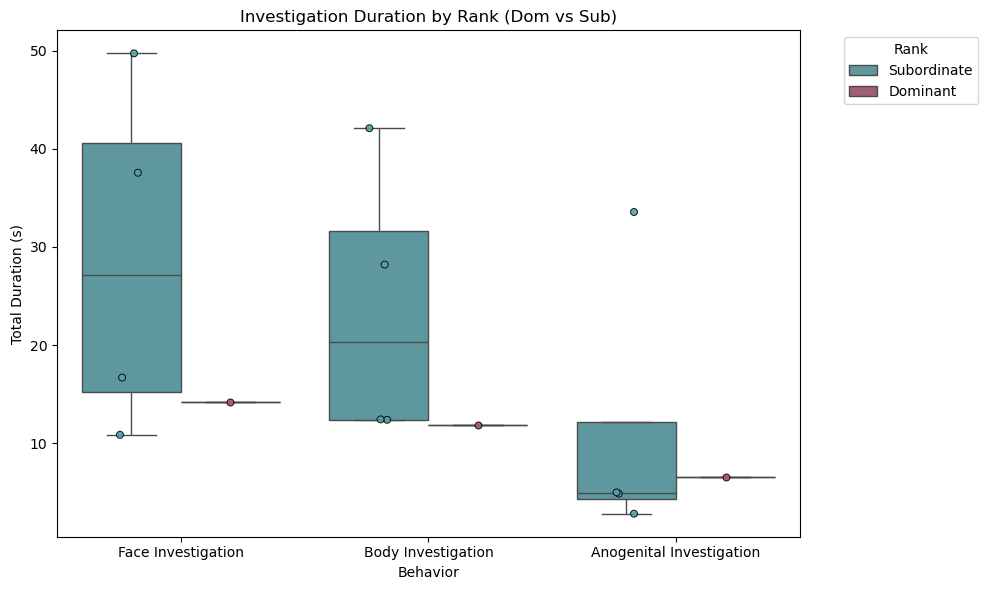

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Fixed rank mapping for your experiment ---
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

# --- Clean and combine BORIS ---
all_bouts = []
for trial, df in boris_data.items():
    temp = df.copy()
    temp["Trial"] = trial
    temp["Condition"] = "Baseline"   # all CM for now

    # Extract Subject_ID from trial name (e.g., CM_1_1_d1_2 → 1_1)
    parts = trial.split("_")
    if len(parts) >= 3:
        temp["Subject_ID"] = parts[1] + "_" + parts[2]
    else:
        temp["Subject_ID"] = "Unknown"

    all_bouts.append(temp)

combined_bouts = pd.concat(all_bouts, ignore_index=True)

# --- Assign fixed Rank from mapping ---
combined_bouts["Rank"] = combined_bouts["Subject_ID"].map(rank_mapping).fillna("Unknown")

print("✅ Subjects with fixed rank mapping:")
print(combined_bouts[["Subject_ID", "Rank"]].drop_duplicates().sort_values("Subject_ID"))

# --- Drop long bouts (>30s) ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# --- Keep only ranked bouts ---
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Restrict to investigation behaviors ---
keep_behaviors = ["Facial Sniffing", "Body Sniffing", "Anogenital Sniffing"]
ranked_bouts = ranked_bouts[ranked_bouts["Behavior"].isin(keep_behaviors)].copy()

# Rename for clarity
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].replace({
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
})

# --- Aggregate total duration per subject × behavior × rank ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Custom palette mapping (positive=subordinate, negative=dominant) ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],
    "Dominant": custom_palette["Negative"],
}

# --- Plot ---
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order
)
sns.stripplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.7, order=behavior_order,
    palette=rank_palette
)

plt.ylabel("Total Duration (s)")
plt.title("Investigation Duration by Rank (Dom vs Sub)")
plt.xticks(rotation=0)

# Avoid duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


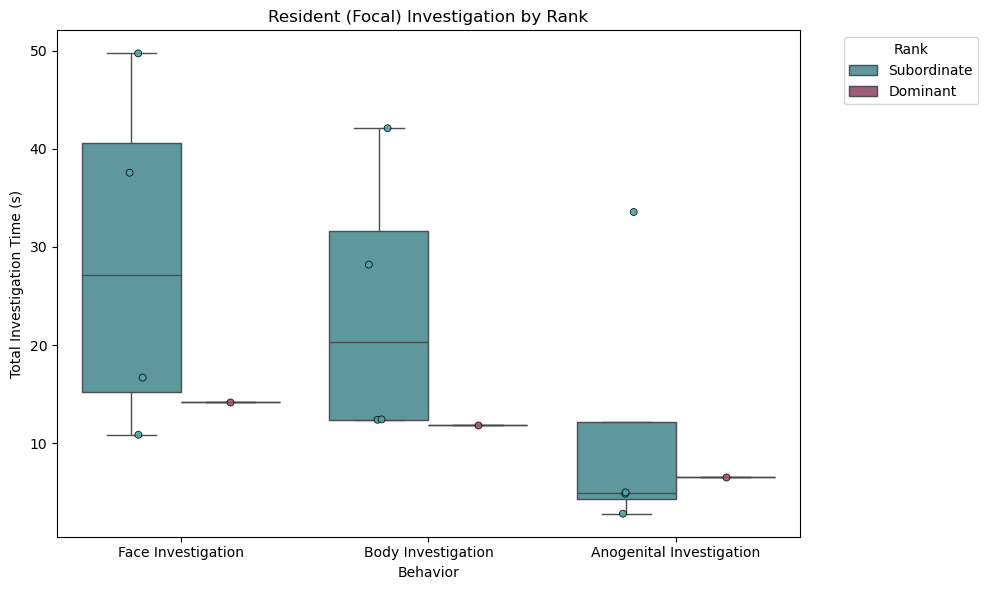

✅ Focal residents contributing to this plot:
Subject_ID  Rank       
1_1         Subordinate    28.128
1_2         Dominant       32.665
2_3         Subordinate    99.336
3_5         Subordinate    96.831
4_7         Subordinate    31.955
Name: Total_Duration, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop long bouts (>30s) ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# --- Keep only ranked bouts (drop Unknown) ---
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Minimum bout filter (≥5 bouts per focal per condition) ---
X = 5
valid_subjects = (
    ranked_bouts.groupby(["Subject_ID", "Rank"])["Behavior"]
    .count()
    .reset_index()
    .query("Behavior >= @X")["Subject_ID"]
    .unique()
)
ranked_bouts = ranked_bouts[ranked_bouts["Subject_ID"].isin(valid_subjects)].copy()

# --- Restrict to investigation behaviors ---
keep_behaviors = ["Facial Sniffing", "Body Sniffing", "Anogenital Sniffing"]
ranked_bouts = ranked_bouts[ranked_bouts["Behavior"].isin(keep_behaviors)].copy()

# --- Rename for clarity ---
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].replace({
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
})

# --- Aggregate per resident (focal) × behavior × rank ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# Add explicit Focal label
agg_durations["Focal"] = "Resident"

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # juvenile-like = positive
    "Dominant": custom_palette["Negative"]      # bully-like = negative
}

# --- Order of behaviors ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot ---
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order
)
sns.stripplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette
)

plt.xticks(rotation=0)
plt.ylabel("Total Investigation Time (s)")
plt.title("Resident (Focal) Investigation by Rank")

# --- Fix duplicate legends ---
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()

# --- Print contributing focal subjects ---
print("✅ Focal residents contributing to this plot:")
print(
    agg_durations.groupby(["Subject_ID", "Rank"])["Total_Duration"]
    .sum()
    .sort_index()
)


In [ ]:
# --- Add Focal column (always the resident Subject_ID) ---
agg_durations["Focal"] = "Resident"

# --- Print subjects contributing to plot ---
print("✅ Subjects contributing (resident focal animals only):")
print(
    agg_durations.groupby(["Subject_ID", "Rank"])["Total_Duration"]
    .sum()
    .sort_index()
)


✅ Subjects contributing (resident focal animals only):
Subject_ID  Rank       
1_1         Subordinate    28.128
1_2         Dominant       32.665
2_3         Subordinate    99.336
3_5         Subordinate    96.831
4_7         Subordinate    31.955
Name: Total_Duration, dtype: float64


In [ ]:
# --- Minimum bouts filter (example: at least 5 per condition) ---
X = 5  # you can change this
valid_subjects = (
    bout_counts
    .groupby(["Subject_ID", "Condition"])["Bout_Count"]
    .sum()
    .reset_index()
    .query("Bout_Count >= @X")["Subject_ID"]
    .unique()
)

filtered_bout_counts = bout_counts[bout_counts["Subject_ID"].isin(valid_subjects)]
print(f"✅ Filtered: {len(valid_subjects)} subjects met minimum {X} bouts")


✅ Filtered: 5 subjects met minimum 5 bouts


In [ ]:
# --- Summarize bouts per behavior ---
behavior_summary = (
    filtered_bout_counts
    .groupby(["Condition", "Behavior"])["Bout_Count"]
    .sum()
    .reset_index()
    .sort_values(["Condition", "Bout_Count"], ascending=[True, False])
)

print("✅ Behavior summary ready")
display(behavior_summary)


✅ Behavior summary ready


,Condition,Behavior,Bout_Count
4,Baseline,Facial Sniffing,172
2,Baseline,Body Sniffing,114
5,Baseline,Fighting,34
3,Baseline,Chasing,33
1,Baseline,Anogenital Sniffing,31
0,Baseline,Allogrooming,12
6,Baseline,Posturing,3


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\981742606.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


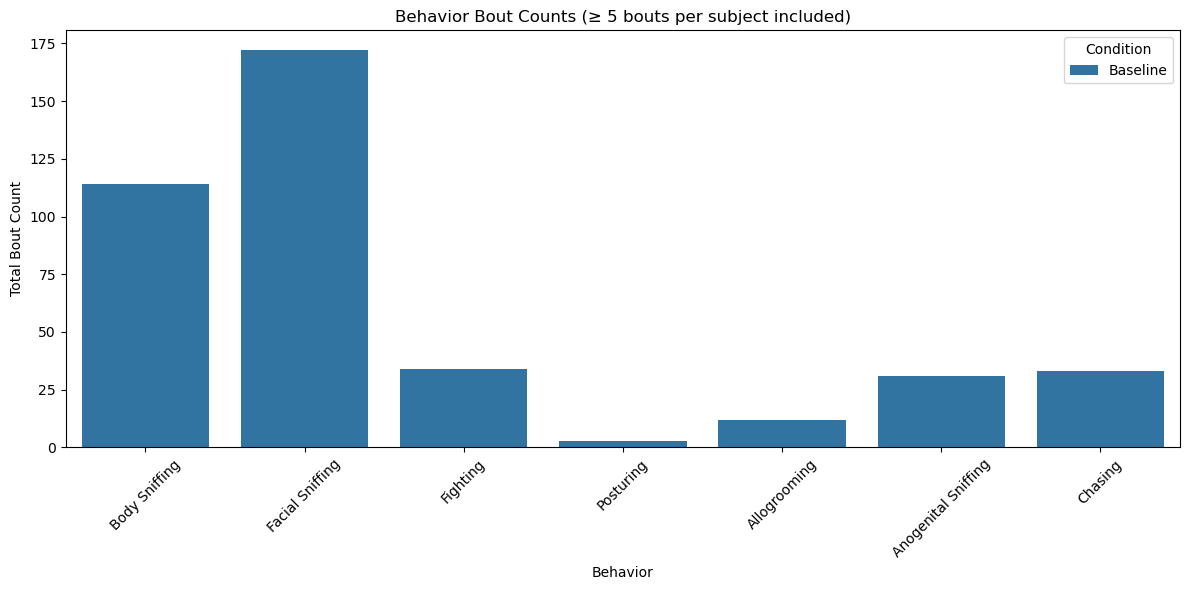

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(
    data=filtered_bout_counts,
    x="Behavior", y="Bout_Count", hue="Condition",
    estimator=sum, ci=None
)
plt.xticks(rotation=45)
plt.ylabel("Total Bout Count")
plt.title(f"Behavior Bout Counts (≥ {X} bouts per subject included)")
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3448992474.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


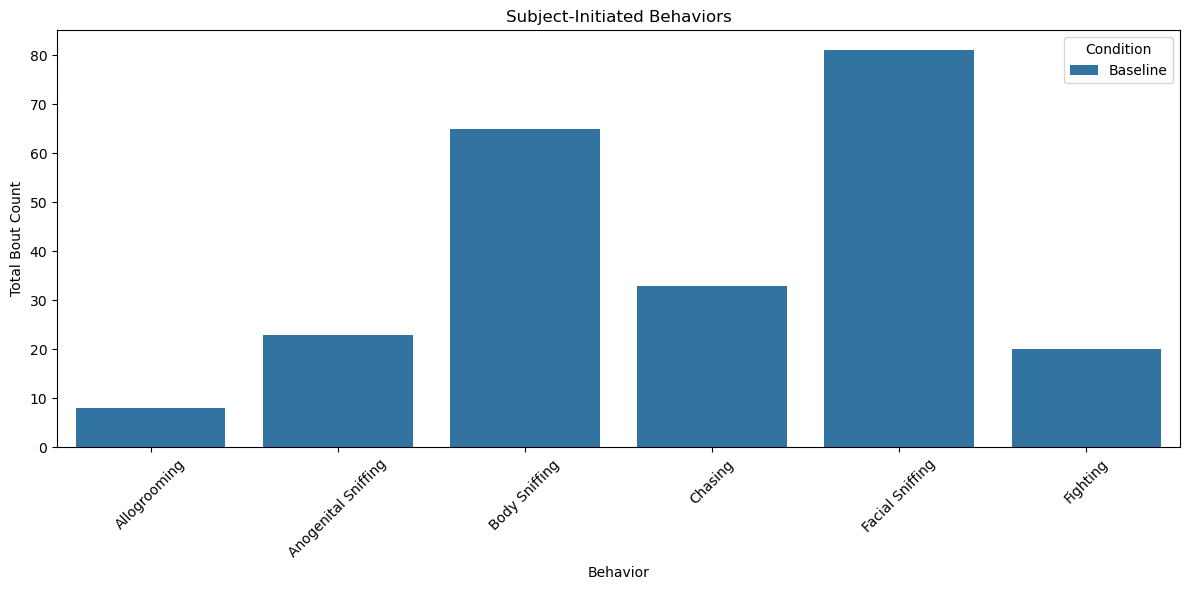

C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3448992474.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


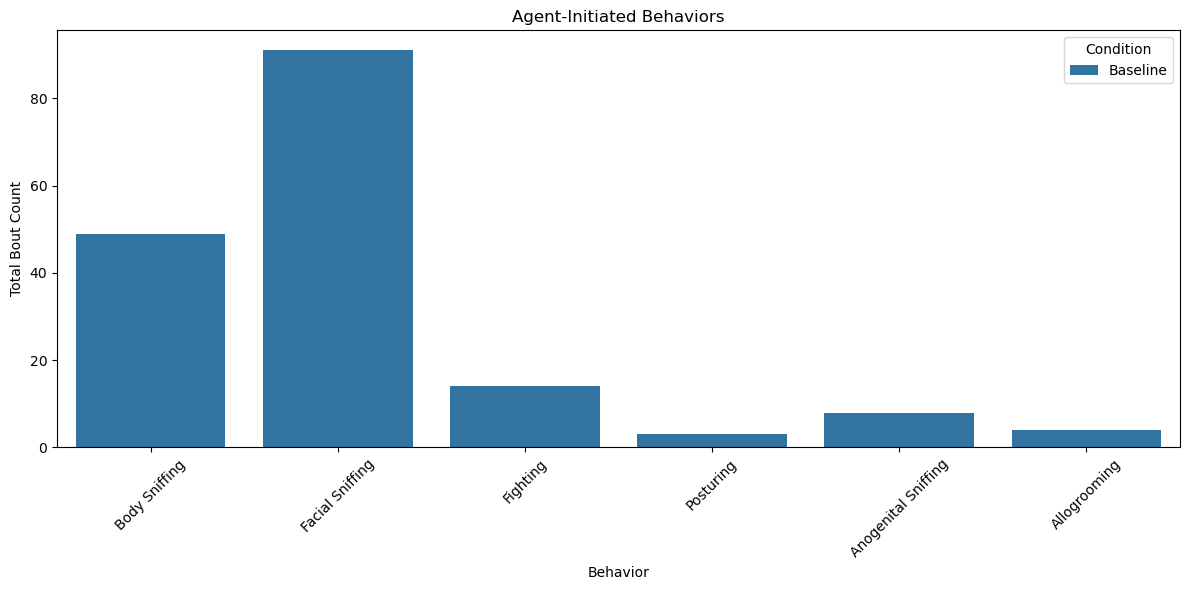

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Subject-initiated behaviors ---
subj_bouts = filtered_bout_counts[filtered_bout_counts["Subject"].str.contains("subject", case=False)]
plt.figure(figsize=(12,6))
sns.barplot(
    data=subj_bouts,
    x="Behavior", y="Bout_Count", hue="Condition",
    estimator=sum, ci=None
)
plt.title("Subject-Initiated Behaviors")
plt.ylabel("Total Bout Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Agent-initiated behaviors ---
agent_bouts = filtered_bout_counts[filtered_bout_counts["Subject"].str.contains("agent", case=False)]
plt.figure(figsize=(12,6))
sns.barplot(
    data=agent_bouts,
    x="Behavior", y="Bout_Count", hue="Condition",
    estimator=sum, ci=None
)
plt.title("Agent-Initiated Behaviors")
plt.ylabel("Total Bout Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\303905104.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


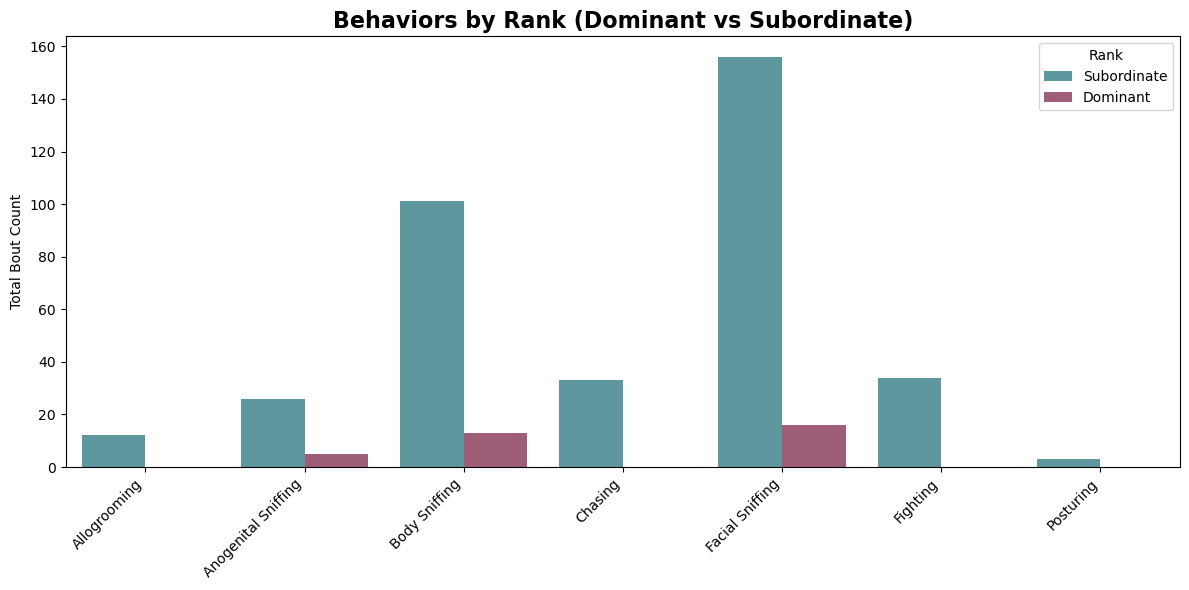

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Keep only bouts with Rank info (drop Unknown) ---
ranked_bouts = combined_bouts[combined_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Aggregate total bout counts per behavior × rank ---
agg_bouts = (
    ranked_bouts
    .groupby(["Behavior", "Rank"], as_index=False)
    .size()
    .rename(columns={"size": "Bout_Count"})
)

# --- Define palette (map Dom = Negative, Sub = Positive) ---
rank_palette = {
    "Dominant": (169/255, 83/255, 118/255),   # magenta = negative
    "Subordinate": (83/255, 161/255, 169/255) # teal = positive
}

# --- Plot ---
plt.figure(figsize=(12,6))
sns.barplot(
    data=agg_bouts,
    x="Behavior", y="Bout_Count", hue="Rank",
    palette=rank_palette, ci=None
)
plt.title("Behaviors by Rank (Dominant vs Subordinate)", fontsize=16, weight="bold")
plt.ylabel("Total Bout Count")
plt.xticks(rotation=45, ha="right")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [ ]:
# Behaviors + Ranks actually included in the plot
print("\n✅ Behaviors included in the plot:")
print(ranked_bouts["Behavior"].unique())

print("\n✅ Subjects contributing data to the plot:")
print(ranked_bouts["Subject_ID"].unique())



✅ Behaviors included in the plot:
['Facial Sniffing' 'Body Sniffing' 'Fighting' 'Chasing' 'Allogrooming'
 'Anogenital Sniffing' 'Posturing' nan]

✅ Subjects contributing data to the plot:
['1_1' '1_2' '2_3' '3_5' '4_7' '4_8']


In [ ]:
# Show which Subject_ID was treated as Dominant vs Subordinate
subject_rank_map = (
    ranked_bouts[["Subject_ID", "Rank"]]
    .drop_duplicates()
    .sort_values("Subject_ID")
)

print("✅ Subject → Rank mapping:")
print(subject_rank_map)


✅ Subject → Rank mapping:
    Subject_ID         Rank
0          1_1  Subordinate
129        1_2     Dominant
163        2_3  Subordinate
260        3_5  Subordinate
350        4_7  Subordinate
399        4_8     Dominant


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3586661113.py:31: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3586661113.py:41: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


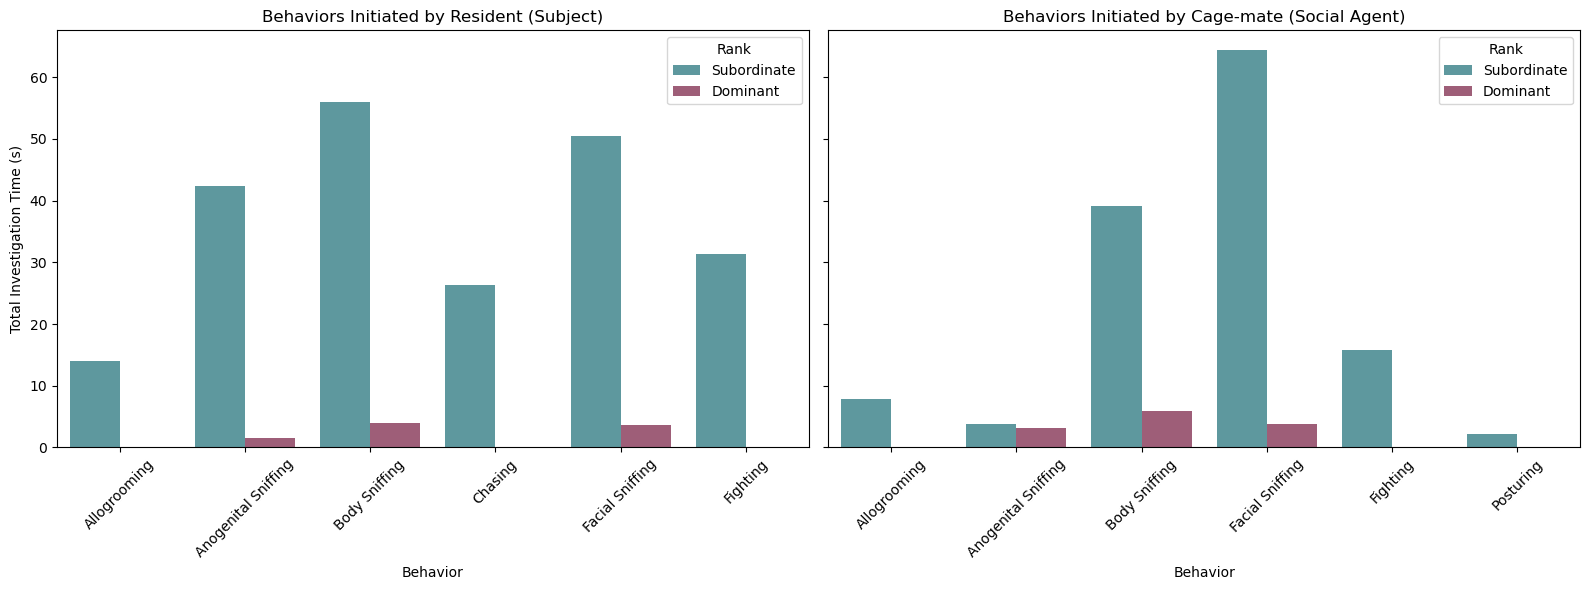

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop Unknown rank + long bouts (>30s) ---
ranked_bouts = combined_bouts[
    combined_bouts["Rank"].isin(["Dominant", "Subordinate"])
].copy()
ranked_bouts = ranked_bouts[ranked_bouts["Duration (s)"] <= 30]

# --- Aggregate total investigation duration ---
initiator_df = (
    ranked_bouts.groupby(["Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by who initiated ---
subj_initiated = initiator_df[initiator_df["Subject"] == "Subject"].copy()
agent_initiated = initiator_df[initiator_df["Subject"] == "Social Agent"].copy()

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # Juvenile-like, positive
    "Dominant": custom_palette["Negative"]      # Bully-like, negative
}

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=True)

# Subject-initiated
sns.barplot(
    data=subj_initiated,
    x="Behavior", y="Total_Duration", hue="Rank",
    estimator=sum, ci=None, ax=axes[0], palette=rank_palette
)
axes[0].set_title("Behaviors Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=45)

# Agent-initiated
sns.barplot(
    data=agent_initiated,
    x="Behavior", y="Total_Duration", hue="Rank",
    estimator=sum, ci=None, ax=axes[1], palette=rank_palette
)
axes[1].set_title("Behaviors Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\4230075162.py:45: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\4230075162.py:56: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


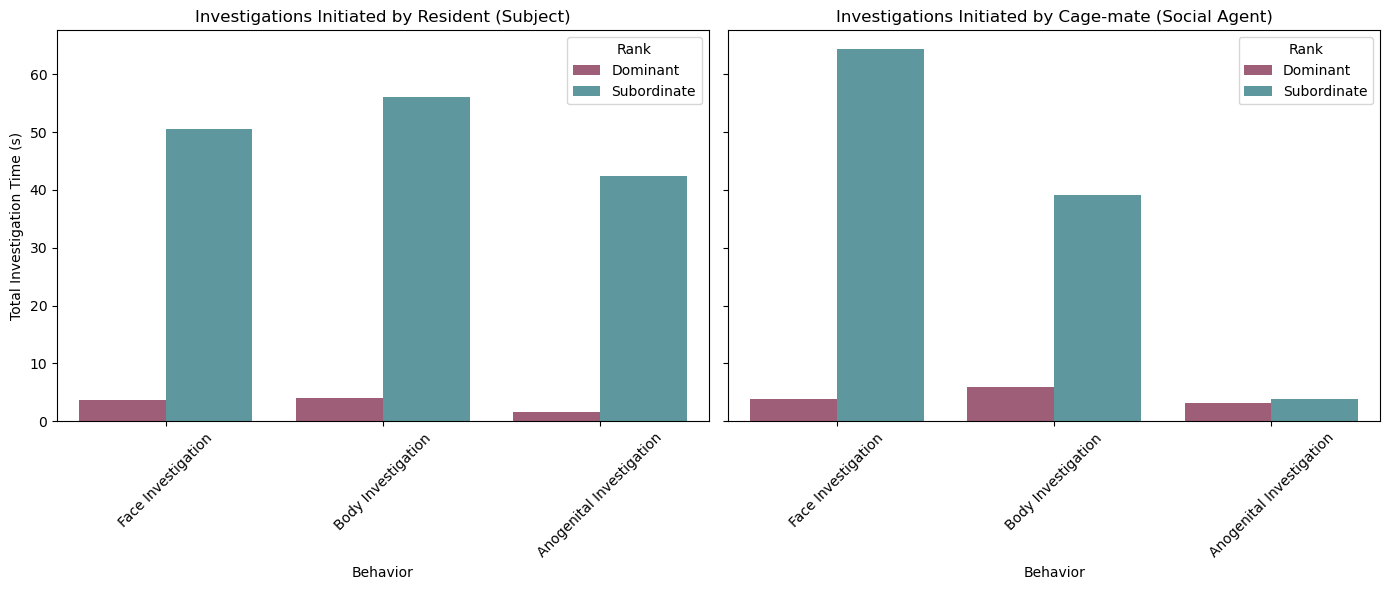

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop Unknown rank + long bouts (>30s) ---
ranked_bouts = combined_bouts[
    combined_bouts["Rank"].isin(["Dominant", "Subordinate"])
].copy()
ranked_bouts = ranked_bouts[ranked_bouts["Duration (s)"] <= 30]

# --- Map behaviors to new labels ---
behavior_map = {
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
}
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].map(behavior_map)

# --- Keep only investigation behaviors ---
investigation_bouts = ranked_bouts[ranked_bouts["Behavior"].notna()]

# --- Aggregate total investigation duration ---
initiator_df = (
    investigation_bouts.groupby(["Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by who initiated ---
subj_initiated = initiator_df[initiator_df["Subject"] == "Subject"].copy()
agent_initiated = initiator_df[initiator_df["Subject"] == "Social Agent"].copy()

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # Juvenile-like, positive
    "Dominant": custom_palette["Negative"]      # Bully-like, negative
}

# --- Set behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Subject-initiated
sns.barplot(
    data=subj_initiated,
    x="Behavior", y="Total_Duration", hue="Rank",
    estimator=sum, ci=None, ax=axes[0], palette=rank_palette,
    order=behavior_order
)
axes[0].set_title("Investigations Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=45)

# Agent-initiated
sns.barplot(
    data=agent_initiated,
    x="Behavior", y="Total_Duration", hue="Rank",
    estimator=sum, ci=None, ax=axes[1], palette=rank_palette,
    order=behavior_order
)
axes[1].set_title("Investigations Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
print("✅ Subjects in Resident-Initiated panel:")
print(subj_initiated.groupby("Rank")["Subject"].unique())

print("\n✅ Subjects in Agent-Initiated panel:")
print(agent_initiated.groupby("Rank")["Subject"].unique())


✅ Subjects in Resident-Initiated panel:
Rank
Dominant       [Subject]
Subordinate    [Subject]
Name: Subject, dtype: object

✅ Subjects in Agent-Initiated panel:
Rank
Dominant       [Social Agent]
Subordinate    [Social Agent]
Name: Subject, dtype: object


In [ ]:
print("Resident-Initiated counts:")
print(subj_initiated.groupby(["Rank"])["Subject"].value_counts())

print("\nAgent-Initiated counts:")
print(agent_initiated.groupby(["Rank"])["Subject"].value_counts())


Resident-Initiated counts:
Rank         Subject
Dominant     Subject    3
Subordinate  Subject    3
Name: count, dtype: int64

Agent-Initiated counts:
Rank         Subject     
Dominant     Social Agent    3
Subordinate  Social Agent    3
Name: count, dtype: int64


In [ ]:
print("Resident-Initiated (Subjects):")
print(subj_initiated.groupby("Rank")["Subject_ID"].unique())

print("\nAgent-Initiated (Social Agents):")
print(agent_initiated.groupby("Rank")["Subject_ID"].unique())

print("\nTotal unique mice with ranks:")
print(ranked_bouts.groupby("Rank")["Subject_ID"].unique())


Resident-Initiated (Subjects):


KeyError: 'Column not found: Subject_ID'

In [ ]:
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}

ranked_bouts["Rank"] = ranked_bouts["Subject_ID"].map(rank_fix)


✅ Subjects per Rank:
Rank
Dominant                      [1_2]
Subordinate    [1_1, 2_3, 3_5, 4_7]
Name: Subject_ID, dtype: object


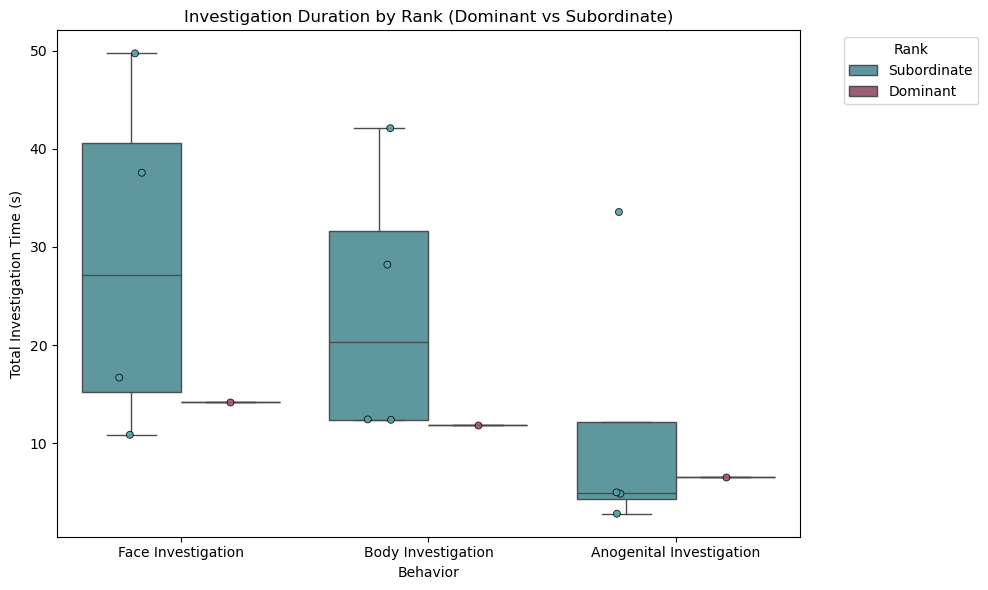

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# --- Assign fixed Rank mapping (permanent identity for each mouse) ---
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}
filtered_bouts["Rank"] = filtered_bouts["Subject_ID"].map(rank_fix)

# --- Keep only Dom/Sub bouts ---
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Restrict to investigation behaviors ---
keep_behaviors = ["Facial Sniffing", "Body Sniffing", "Anogenital Sniffing"]
ranked_bouts = ranked_bouts[ranked_bouts["Behavior"].isin(keep_behaviors)].copy()

# --- Rename for clarity (Sniffing → Investigation) ---
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].replace({
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
})

# --- Aggregate total investigation duration per subject ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Color palette (Dom = negative, Sub = positive) ---
rank_palette = {
    "Dominant": (169/255, 83/255, 118/255),   # magenta
    "Subordinate": (83/255, 161/255, 169/255) # teal
}

# --- Debug: check subjects in each group ---
print("✅ Subjects per Rank:")
print(agg_durations.groupby("Rank")["Subject_ID"].unique())

# --- Plot ---
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order
)
sns.stripplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order, palette=rank_palette
)

plt.xticks(rotation=0)
plt.ylabel("Total Investigation Time (s)")
plt.title("Investigation Duration by Rank (Dominant vs Subordinate)")

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


✅ Resident-Initiated (Subjects):
Rank
Dominant                      [1_2]
Subordinate    [1_1, 2_3, 3_5, 4_7]
Name: Subject_ID, dtype: object

✅ Agent-Initiated (Social Agents):
Rank
Dominant                      [1_2]
Subordinate    [1_1, 2_3, 3_5, 4_7]
Name: Subject_ID, dtype: object


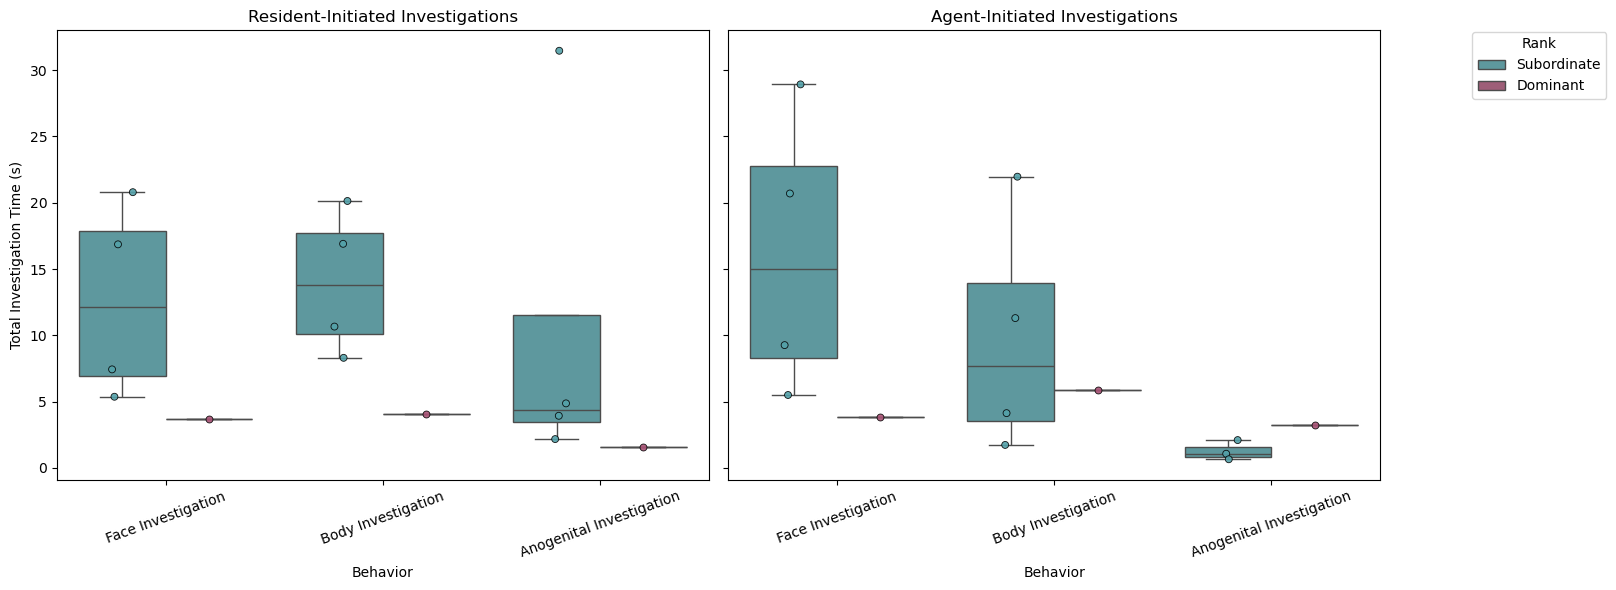

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# --- Assign fixed Rank mapping (permanent identity for each mouse) ---
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}
filtered_bouts["Rank"] = filtered_bouts["Subject_ID"].map(rank_fix)

# --- Keep only Dom/Sub bouts ---
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Restrict to investigation behaviors ---
keep_behaviors = ["Facial Sniffing", "Body Sniffing", "Anogenital Sniffing"]
ranked_bouts = ranked_bouts[ranked_bouts["Behavior"].isin(keep_behaviors)].copy()

# --- Rename for clarity (Sniffing → Investigation) ---
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].replace({
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
})

# --- Aggregate total investigation duration per subject × initiator ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by initiator ---
resident_df = agg_durations[agg_durations["Subject"] == "Subject"].copy()
agent_df = agg_durations[agg_durations["Subject"] == "Social Agent"].copy()

# --- Behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Color palette (Dom = negative, Sub = positive) ---
rank_palette = {
    "Dominant": (169/255, 83/255, 118/255),   # magenta
    "Subordinate": (83/255, 161/255, 169/255) # teal
}

# --- Debug: confirm subjects per group ---
print("✅ Resident-Initiated (Subjects):")
print(resident_df.groupby("Rank")["Subject_ID"].unique())
print("\n✅ Agent-Initiated (Social Agents):")
print(agent_df.groupby("Rank")["Subject_ID"].unique())

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Resident-initiated
sns.boxplot(
    data=resident_df, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[0]
)
sns.stripplot(
    data=resident_df, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[0]
)
axes[0].set_title("Resident-Initiated Investigations")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=20)

# Agent-initiated
sns.boxplot(
    data=agent_df, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[1]
)
sns.stripplot(
    data=agent_df, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[1]
)
axes[1].set_title("Agent-Initiated Investigations")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=20)

# --- Clean up duplicate legends ---
for ax in axes:
    ax.legend_.remove()
fig.legend(handles=axes[0].get_legend_handles_labels()[0][:2],
           labels=axes[0].get_legend_handles_labels()[1][:2],
           bbox_to_anchor=(1.05, 0.95), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


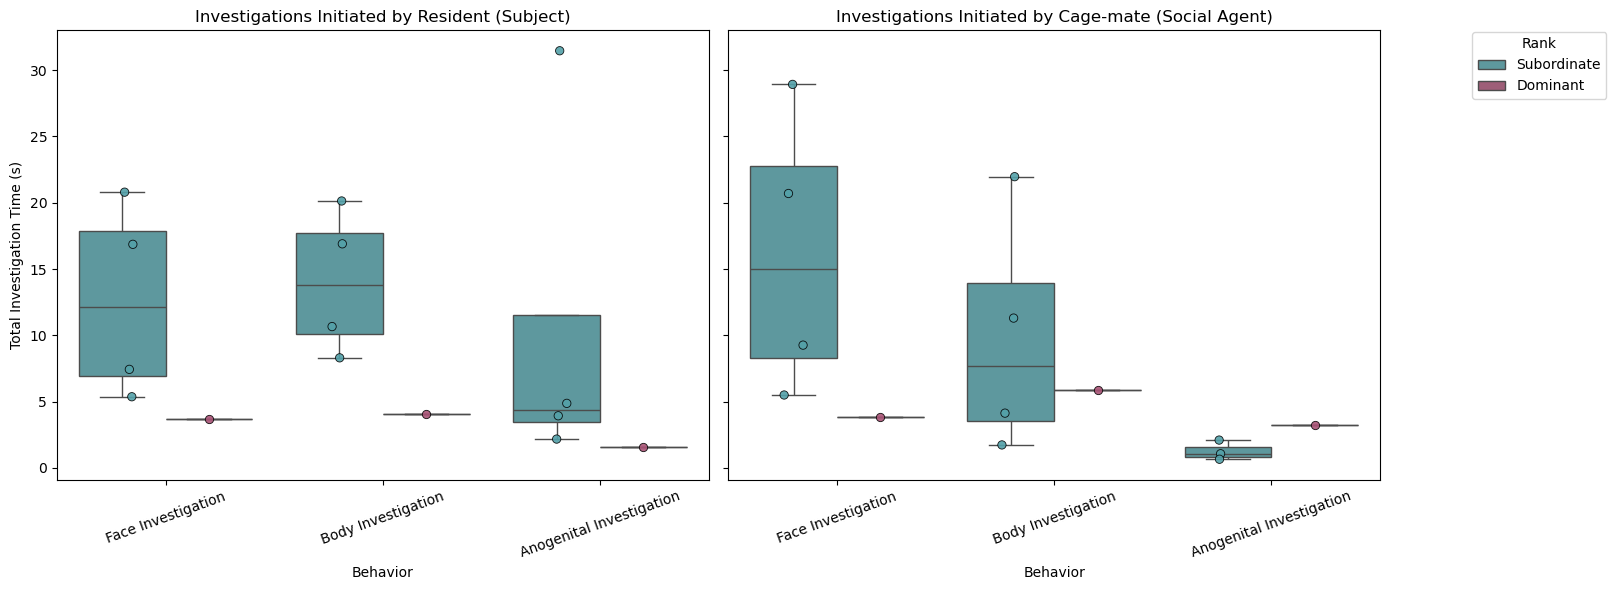

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1. Drop bouts longer than 30s ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# --- Step 2. Define manual subject → rank mapping ---
rank_map = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}

# Add Rank column using Subject_ID
filtered_bouts["Rank"] = filtered_bouts["Subject_ID"].map(rank_map)

# --- Step 3. Map behaviors to investigation categories ---
behavior_map = {
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
}
filtered_bouts["Behavior"] = filtered_bouts["Behavior"].map(behavior_map)

# Keep only investigation bouts
investigation_bouts = filtered_bouts[filtered_bouts["Behavior"].notna()]

# --- Step 4. Aggregate investigation duration ---
initiator_df = (
    investigation_bouts.groupby(["Subject_ID", "Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# Split by initiator
subj_initiated = initiator_df[initiator_df["Subject"] == "Subject"].copy()
agent_initiated = initiator_df[initiator_df["Subject"] == "Social Agent"].copy()

# --- Step 5. Define palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # map to positive color
    "Dominant": custom_palette["Negative"]      # map to negative color
}

behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Step 6. Plot side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Resident-initiated
sns.boxplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette, fliersize=0, ax=axes[0]
)
sns.stripplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, dodge=True, jitter=True, alpha=0.9, size=6,
    marker="o", edgecolor="black", linewidth=0.6, palette=rank_palette, ax=axes[0]
)
axes[0].set_title("Investigations Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=20)

# Cage-mate initiated
sns.boxplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette, fliersize=0, ax=axes[1]
)
sns.stripplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, dodge=True, jitter=True, alpha=0.9, size=6,
    marker="o", edgecolor="black", linewidth=0.6, palette=rank_palette, ax=axes[1]
)
axes[1].set_title("Investigations Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=20)

# --- Shared legend ---
for ax in axes:
    ax.legend_.remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 0.95), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


In [ ]:
# --- Your mapping of who is Dom vs Sub ---
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

# --- Assign correct ranks ---
ranked_bouts = combined_bouts.copy()

# Drop long bouts (>30s)
ranked_bouts = ranked_bouts[ranked_bouts["Duration (s)"] <= 30]

# Extract Subject_ID (like 1_1, 2_3, etc.) from Trial name
ranked_bouts["Subject_ID"] = ranked_bouts["Trial"].str.extract(r"CM_(\d+_\d+)")

# Map the Subject_ID to its rank
ranked_bouts["Correct_Rank"] = ranked_bouts["Subject_ID"].map(rank_mapping)

# If the bout is from the Social Agent, flip to the partner’s rank
def get_rank(row):
    sid = row["Subject_ID"]
    if pd.isna(sid):
        return "Unknown"
    if row["Subject"] == "Subject":
        return rank_mapping.get(sid, "Unknown")
    else:
        # Flip: if Subject is Subordinate, Agent must be Dominant, and vice versa
        return "Dominant" if rank_mapping.get(sid) == "Subordinate" else "Subordinate"

ranked_bouts["Rank"] = ranked_bouts.apply(get_rank, axis=1)

print(ranked_bouts[["Trial", "Subject", "Subject_ID", "Rank"]].drop_duplicates().head(20))


             Trial           Subject Subject_ID         Rank
0      CM_1_1_d1_2      Social Agent        1_1     Dominant
1      CM_1_1_d1_2           Subject        1_1  Subordinate
129  CM_1_2_sub1_1      Social Agent        1_2  Subordinate
132  CM_1_2_sub1_1           Subject        1_2     Dominant
151  CM_1_2_sub1_1  No Focal Subject        1_2  Subordinate
163    CM_2_3_d2_4      Social Agent        2_3     Dominant
164    CM_2_3_d2_4           Subject        2_3  Subordinate
260    CM_3_5_d3_6           Subject        3_5  Subordinate
261    CM_3_5_d3_6      Social Agent        3_5     Dominant
350    CM_4_7_d4_8           Subject        4_7  Subordinate
352    CM_4_7_d4_8      Social Agent        4_7     Dominant


In [ ]:
# Mapping for the actual rank of each Subject_ID
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

def assign_rank(row):
    sid = row["Subject_ID"]
    base_rank = rank_mapping.get(sid, "Unknown")

    # If Social Agent, flip rank
    if row["Subject"] == "Social Agent":
        if base_rank == "Subordinate":
            return "Dominant"
        elif base_rank == "Dominant":
            return "Subordinate"
        else:
            return "Unknown"
    else:
        return base_rank

ranked_bouts["Rank"] = ranked_bouts.apply(assign_rank, axis=1)

print(ranked_bouts[["Trial", "Subject", "Subject_ID", "Rank"]].drop_duplicates().head(20))


             Trial           Subject Subject_ID         Rank
0      CM_1_1_d1_2      Social Agent        1_1     Dominant
1      CM_1_1_d1_2           Subject        1_1  Subordinate
129  CM_1_2_sub1_1      Social Agent        1_2  Subordinate
132  CM_1_2_sub1_1           Subject        1_2     Dominant
151  CM_1_2_sub1_1  No Focal Subject        1_2     Dominant
163    CM_2_3_d2_4      Social Agent        2_3     Dominant
164    CM_2_3_d2_4           Subject        2_3  Subordinate
260    CM_3_5_d3_6           Subject        3_5  Subordinate
261    CM_3_5_d3_6      Social Agent        3_5     Dominant
350    CM_4_7_d4_8           Subject        4_7  Subordinate
352    CM_4_7_d4_8      Social Agent        4_7     Dominant


In [ ]:
import re

# Trial name patterns look like: CM_1_1_d1_2  or  CM_1_2_sub1_1
def parse_ids_from_trial(trial_name):
    # Extract two IDs (like 1_1 and 1_2, or 3_5 and 3_6)
    matches = re.findall(r'(\d+_\d+)', trial_name)
    if len(matches) == 2:
        return matches[0], matches[1]
    return None, None

# Rank mapping
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

def assign_subject_and_rank(row):
    trial = row["Trial"]
    sid1, sid2 = parse_ids_from_trial(trial)

    if row["Subject"] == "Subject":
        row["Subject_ID"] = sid1
        row["Rank"] = rank_mapping.get(sid1, "Unknown")
    elif row["Subject"] == "Social Agent":
        row["Subject_ID"] = sid2
        row["Rank"] = rank_mapping.get(sid2, "Unknown")
    else:
        row["Subject_ID"] = None
        row["Rank"] = "Unknown"

    return row

# Apply fix
ranked_bouts = ranked_bouts.apply(assign_subject_and_rank, axis=1)

# Quick check
print(ranked_bouts[["Trial", "Subject", "Subject_ID", "Rank"]].drop_duplicates().head(20))


             Trial           Subject Subject_ID         Rank
0      CM_1_1_d1_2      Social Agent        1_2     Dominant
1      CM_1_1_d1_2           Subject        1_1  Subordinate
129  CM_1_2_sub1_1      Social Agent        1_1  Subordinate
132  CM_1_2_sub1_1           Subject        1_2     Dominant
151  CM_1_2_sub1_1  No Focal Subject       None      Unknown
163    CM_2_3_d2_4      Social Agent        2_4     Dominant
164    CM_2_3_d2_4           Subject        2_3  Subordinate
260    CM_3_5_d3_6           Subject        3_5  Subordinate
261    CM_3_5_d3_6      Social Agent        3_6     Dominant
350    CM_4_7_d4_8           Subject        4_7  Subordinate
352    CM_4_7_d4_8      Social Agent        4_8     Dominant


In [ ]:
import re

# --- Function to parse subject IDs from trial name ---
def parse_ids_from_trial(trial_name):
    # Extracts IDs like "1_1", "1_2" from strings like CM_1_1_d1_2 or CM_1_2_sub1_1
    matches = re.findall(r'(\d+_\d+)', trial_name)
    if len(matches) == 2:
        return matches[0], matches[1]
    return None, None

# --- Define your known rank mapping ---
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

# --- Function to assign Subject_ID and Rank row-by-row ---
def assign_subject_and_rank(row):
    trial = row["Trial"]
    sid1, sid2 = parse_ids_from_trial(trial)

    if row["Subject"] == "Subject":
        row["Subject_ID"] = sid1
        row["Rank"] = rank_mapping.get(sid1, "Unknown")
    elif row["Subject"] == "Social Agent":
        row["Subject_ID"] = sid2
        row["Rank"] = rank_mapping.get(sid2, "Unknown")
    else:
        row["Subject_ID"] = None
        row["Rank"] = "Unknown"

    return row

# --- Apply mapping to your dataframe ---
ranked_bouts = ranked_bouts.apply(assign_subject_and_rank, axis=1)

# --- Quick sanity check ---
print("✅ Assigned IDs + Ranks:")
print(ranked_bouts[["Trial", "Subject", "Subject_ID", "Rank"]].drop_duplicates().head(20))


✅ Assigned IDs + Ranks:
             Trial           Subject Subject_ID         Rank
0      CM_1_1_d1_2      Social Agent        1_2     Dominant
1      CM_1_1_d1_2           Subject        1_1  Subordinate
129  CM_1_2_sub1_1      Social Agent        1_1  Subordinate
132  CM_1_2_sub1_1           Subject        1_2     Dominant
151  CM_1_2_sub1_1  No Focal Subject       None      Unknown
163    CM_2_3_d2_4      Social Agent        2_4     Dominant
164    CM_2_3_d2_4           Subject        2_3  Subordinate
260    CM_3_5_d3_6           Subject        3_5  Subordinate
261    CM_3_5_d3_6      Social Agent        3_6     Dominant
350    CM_4_7_d4_8           Subject        4_7  Subordinate
352    CM_4_7_d4_8      Social Agent        4_8     Dominant


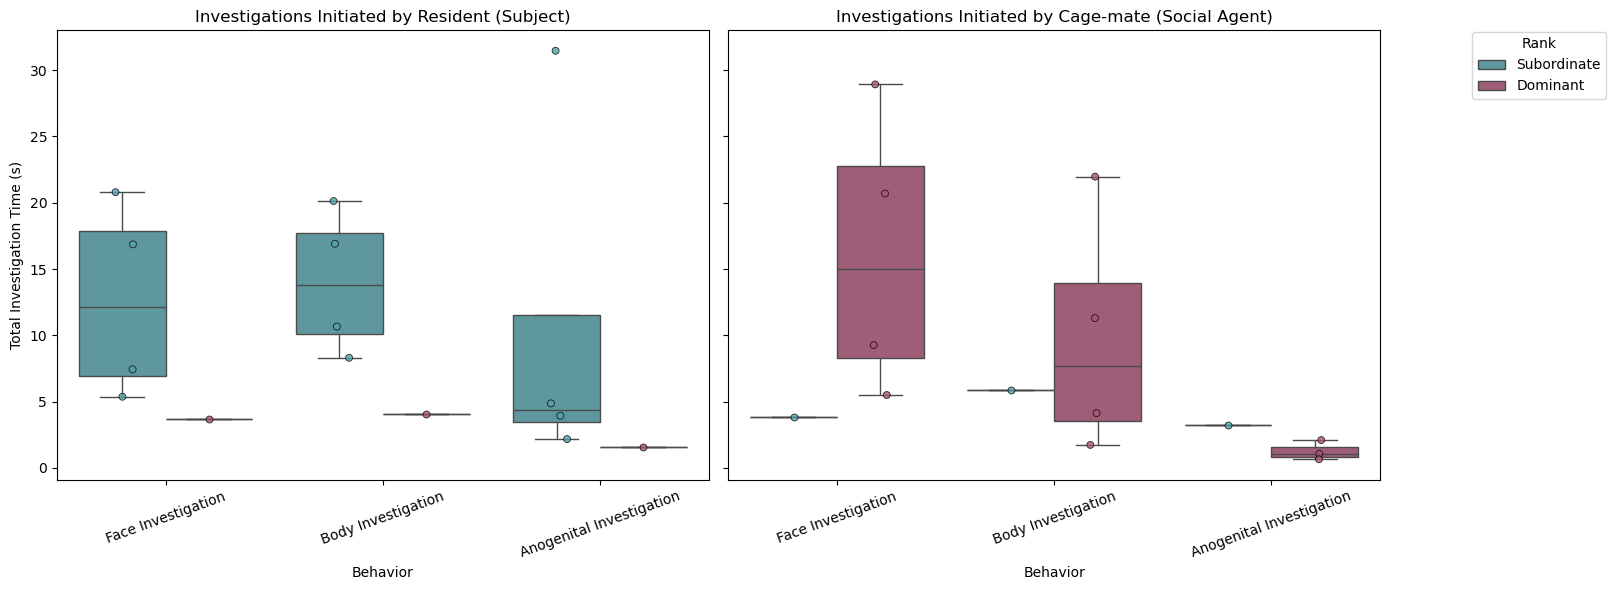

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = ranked_bouts[ranked_bouts["Duration (s)"] <= 30].copy()

# --- Map behaviors to new labels ---
behavior_map = {
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
}
filtered_bouts["Behavior"] = filtered_bouts["Behavior"].map(behavior_map)

# --- Keep only investigation behaviors ---
investigation_bouts = filtered_bouts[filtered_bouts["Behavior"].notna()]

# --- Aggregate total investigation duration ---
agg_durations = (
    investigation_bouts.groupby(["Subject_ID", "Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by initiator ---
subj_initiated = agg_durations[agg_durations["Subject"] == "Subject"].copy()
agent_initiated = agg_durations[agg_durations["Subject"] == "Social Agent"].copy()

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # Sub → positive / juvenile-like
    "Dominant": custom_palette["Negative"]      # Dom → negative / bully-like
}

# --- Behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Resident (Subject) initiated
sns.boxplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette, fliersize=0, ax=axes[0]
)
sns.stripplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette,
    dodge=True, jitter=True, marker="o", size=5, alpha=0.8,
    edgecolor="black", linewidth=0.6, ax=axes[0]
)
axes[0].set_title("Investigations Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=20)

# Cage-mate (Social Agent) initiated
sns.boxplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette, fliersize=0, ax=axes[1]
)
sns.stripplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    order=behavior_order, palette=rank_palette,
    dodge=True, jitter=True, marker="o", size=5, alpha=0.8,
    edgecolor="black", linewidth=0.6, ax=axes[1]
)
axes[1].set_title("Investigations Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=20)

# --- Fix duplicate legends ---
for ax in axes:
    if ax.get_legend():
        ax.get_legend().remove()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 0.95), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


In [ ]:
print("Unique Subject values:", agg_durations["Subject"].unique())


Unique Subject values: ['Social Agent' 'Subject']


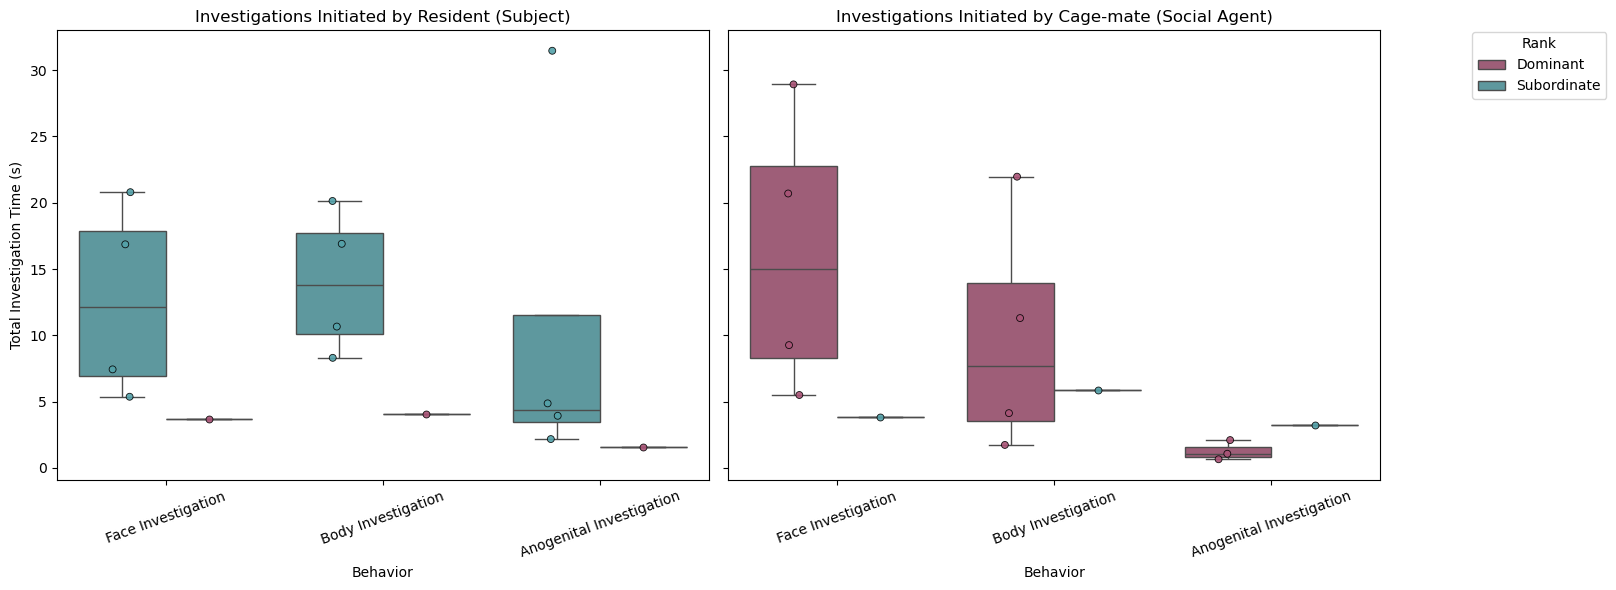

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop Unknown rank + long bouts (>30s) ---
ranked_bouts = combined_bouts[
    combined_bouts["Rank"].isin(["Dominant", "Subordinate"])
].copy()
ranked_bouts = ranked_bouts[ranked_bouts["Duration (s)"] <= 30]

# --- Map behaviors to new labels ---
behavior_map = {
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
}
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].map(behavior_map)

# --- Keep only investigation behaviors ---
investigation_bouts = ranked_bouts[ranked_bouts["Behavior"].notna()]

# --- Aggregate total investigation duration ---
initiator_df = (
    investigation_bouts.groupby(["Subject_ID", "Behavior", "Rank", "Subject"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by who initiated ---
subj_initiated = initiator_df[initiator_df["Subject"] == "Subject"].copy()
agent_initiated = initiator_df[initiator_df["Subject"] == "Social Agent"].copy()

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # Juvenile-like, positive
    "Dominant": custom_palette["Negative"]      # Bully-like, negative
}

# --- Set behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Subject-initiated
sns.boxplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[0]
)
sns.stripplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[0]
)
axes[0].set_title("Investigations Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=20)

# Agent-initiated
sns.boxplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[1]
)
sns.stripplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[1]
)
axes[1].set_title("Investigations Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=20)

# --- Fix duplicate legends ---
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()
fig.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 0.95), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\947294356.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


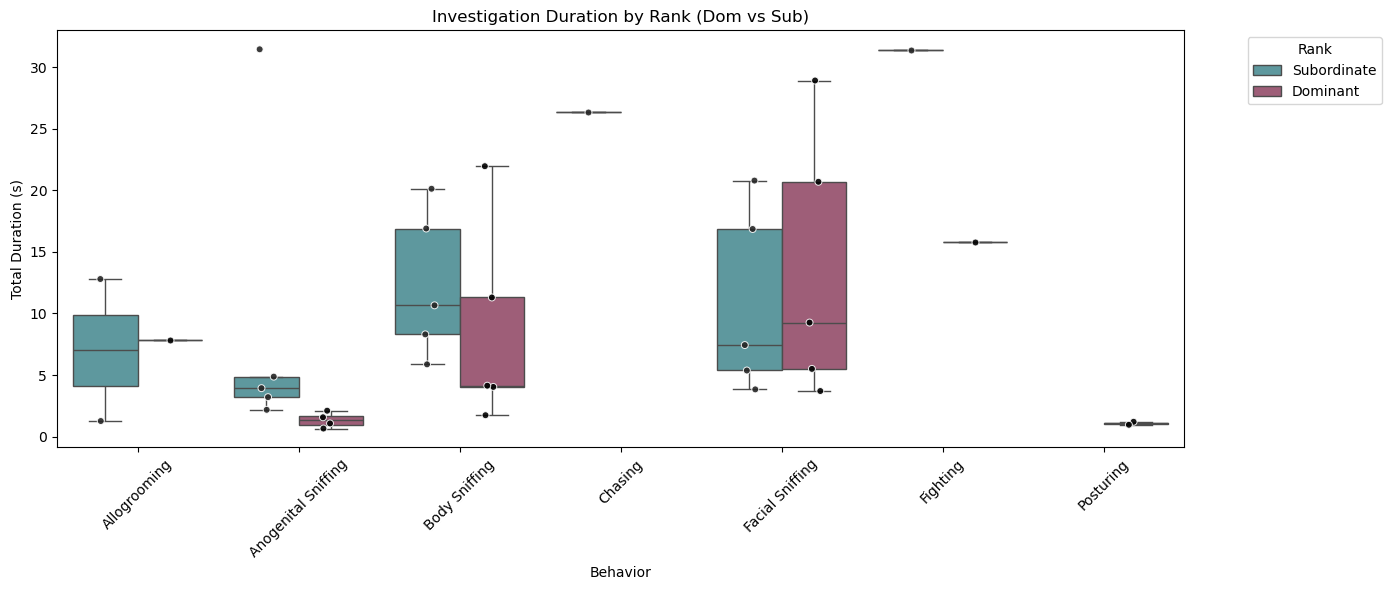

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# Keep only ranked bouts (drop Unknown)
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Map Rank to Valence palette ---
rank_palette = {
    "Dominant": custom_palette["Negative"],    # bully/negative
    "Subordinate": custom_palette["Positive"]  # juvenile/positive
}

# --- Aggregate total duration per subject × behavior × rank ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Plot ---
plt.figure(figsize=(14,6))
sns.boxplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0
)
sns.stripplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="white", linewidth=0.7, color="black"   # black dots w/ white outline
)

plt.xticks(rotation=45)
plt.ylabel("Total Duration (s)")
plt.title("Investigation Duration by Rank (Dom vs Sub)")

# Avoid double legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3120483679.py:43: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


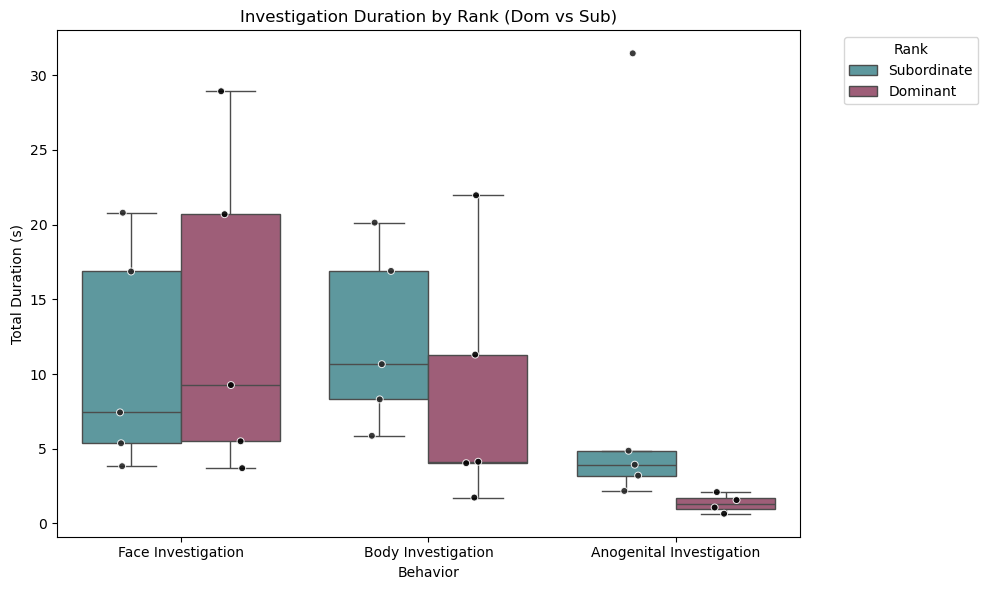

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# Keep only ranked bouts (drop Unknown)
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Map Rank to Valence palette ---
rank_palette = {
    "Dominant": custom_palette["Negative"],    # bully/negative
    "Subordinate": custom_palette["Positive"]  # juvenile/positive
}

# --- Aggregate total duration per subject × behavior × rank ---
agg_durations = (
    ranked_bouts.groupby(["Subject_ID", "Behavior", "Rank"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Restrict to investigations ---
keep_behaviors = ["Facial Sniffing", "Body Sniffing", "Anogenital Sniffing"]
agg_durations = agg_durations[agg_durations["Behavior"].isin(keep_behaviors)].copy()

# Rename for clarity (Sniffing → Investigation)
agg_durations["Behavior"] = agg_durations["Behavior"].replace({
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
})

# Ensure correct order
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot ---
plt.figure(figsize=(10,6))
sns.boxplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order
)
sns.stripplot(
    data=agg_durations, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="white", linewidth=0.7, color="black", order=behavior_order
)

plt.xticks(rotation=0)
plt.ylabel("Total Duration (s)")
plt.title("Investigation Duration by Rank (Dom vs Sub)")

# Avoid double legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


In [ ]:
rank_mapping = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}


In [ ]:
# Overwrite Rank with fixed mapping
combined_bouts["Rank"] = combined_bouts["Subject_ID"].map(rank_mapping).fillna("Unknown")

# Debug check
print(combined_bouts[["Subject_ID", "Rank"]].drop_duplicates().sort_values("Subject_ID"))


    Subject_ID         Rank
0          1_1  Subordinate
129        1_2     Dominant
163        2_3  Subordinate
260        3_5  Subordinate
350        4_7  Subordinate
399        NaN      Unknown


In [ ]:
# How many unique subjects remain?
n_subjects = agg_durations["Subject_ID"].nunique()
subjects_list = agg_durations["Subject_ID"].unique()

print(f"✅ {n_subjects} subjects remain after filtering")
print("Subjects:", subjects_list)


✅ 5 subjects remain after filtering
Subjects: ['1_1' '1_2' '2_3' '3_5' '4_7']


In [ ]:
combined_bouts.query("Behavior == 'Anogenital Sniffing'").sort_values("Duration (s)", ascending=False).head(10)


,Observation id,Observation date,Description,Observation type,Source,Time offset (s),Coding duration,Media duration (s),FPS (frame/s),Subject,Observation duration by subject by observation,Behavior,Behavioral category,Behavior type,Start (s),Stop (s),Duration (s),Media file name,Image index start,Image index stop,Image file path start,Image file path stop,Comment start,Comment stop,Rank,Subject_ID,Agent_ID,Trial,Condition,Observation id\tObservation date\tDescription\tObservation type\tSource\tTime offset (s)\tCoding duration\tMedia duration (s)\tFPS (frame/s)\tSubject\tObservation duration by subject by observation\tBehavior\tBehavioral category\tBehavior type\tStart (s)\tStop (s)\tDuration (s)\tMedia file name\tImage index start\tImage index stop\tImage file path start\tImage file path stop\tComment start\tComment stop
192,CM_s2_3_d2_4_20250623_151153.1,2025-08-25 23:33:03.708,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,0.0,585.633,610.100,30.0,Subject,591.436,Anogenital Sniffing,Not defined,STATE,106.900,539.233,432.333,C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,3207.0,16178.0,NaN,NaN,NaN,NaN,Subordinate,2_3,2_4,CM_2_3_d2_4,Baseline,NaN
178,CM_s2_3_d2_4_20250623_151153.1,2025-08-25 23:33:03.708,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,0.0,585.633,610.100,30.0,Subject,591.436,Anogenital Sniffing,Not defined,STATE,51.733,104.600,52.867,C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,1552.0,3138.0,NaN,NaN,NaN,NaN,Subordinate,2_3,2_4,CM_2_3_d2_4,Baseline,NaN
254,CM_s2_3_d2_4_20250623_151153.1,2025-08-25 23:33:03.708,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,0.0,585.633,610.100,30.0,Subject,591.436,Anogenital Sniffing,Not defined,STATE,539.600,580.600,41.000,C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,16189.0,17419.0,NaN,NaN,NaN,NaN,Subordinate,2_3,2_4,CM_2_3_d2_4,Baseline,NaN
167,CM_s2_3_d2_4_20250623_151153.1,2025-08-25 23:33:03.708,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,0.0,585.633,610.100,30.0,Subject,591.436,Anogenital Sniffing,Not defined,STATE,21.400,50.667,29.267,C:/Users/Tanish/Downloads/CM_s2_3_d2_4_20250623_151153.1.mp4,642.0,1520.0,NaN,NaN,NaN,NaN,Subordinate,2_3,2_4,CM_2_3_d2_4,Baseline,NaN
267,CM_s3_5_d3_6_20250623_160001,2025-09-08 18:38:12.700,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s3_5_d3_6_20250623_160001.1.mp4,0.0,582.300,602.967,30.0,Subject,44.866,Anogenital Sniffing,Not defined,STATE,19.967,23.000,3.033,C:/Users/Tanish/Downloads/CM_s3_5_d3_6_20250623_160001.1.mp4,599.0,690.0,NaN,NaN,NaN,NaN,Subordinate,3_5,3_6,CM_3_5_d3_6,Baseline,NaN
162,CM_s1_2_sub1_1_20250623_1339321.1,2025-08-25 22:28:01.026,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,0.0,561.966,604.867,30.0,No Focal Subject,10.465,Anogenital Sniffing,Not defined,STATE,568.700,570.533,1.833,C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,17062.0,17117.0,NaN,NaN,NaN,NaN,Unknown,1_2,1_1,CM_1_2_sub1_1,Baseline,NaN
147,CM_s1_2_sub1_1_20250623_1339321.1,2025-08-25 22:28:01.026,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,0.0,561.966,604.867,30.0,Social Agent,12.901,Anogenital Sniffing,Not defined,STATE,284.267,285.867,1.600,C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,8528.0,8576.0,NaN,NaN,NaN,NaN,Subordinate,1_2,1_1,CM_1_2_sub1_1,Baseline,NaN
140,CM_s1_2_sub1_1_20250623_1339321.1,2025-08-25 22:28:01.026,NaN,Media file,player #1:C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,0.0,561.966,604.867,30.0,Subject,9.299,Anogenital Sniffing,Not defined,STATE,98.967,100.533,1.566,C:/Users/Tanish/Downloads/CM_s1_2_sub1_1_20250623_133932.1.mp4,2969.0,3016.0,NaN,NaN,NaN,NaN,Dominant,1_2,1_1,CM_1_2_sub1_1,Baseline,NaN
111,CM_s1_1_d1_2_20250623_111352.1,2025-08-25 19:41:37.591,NaN,Media file,player #1

C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3731122592.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


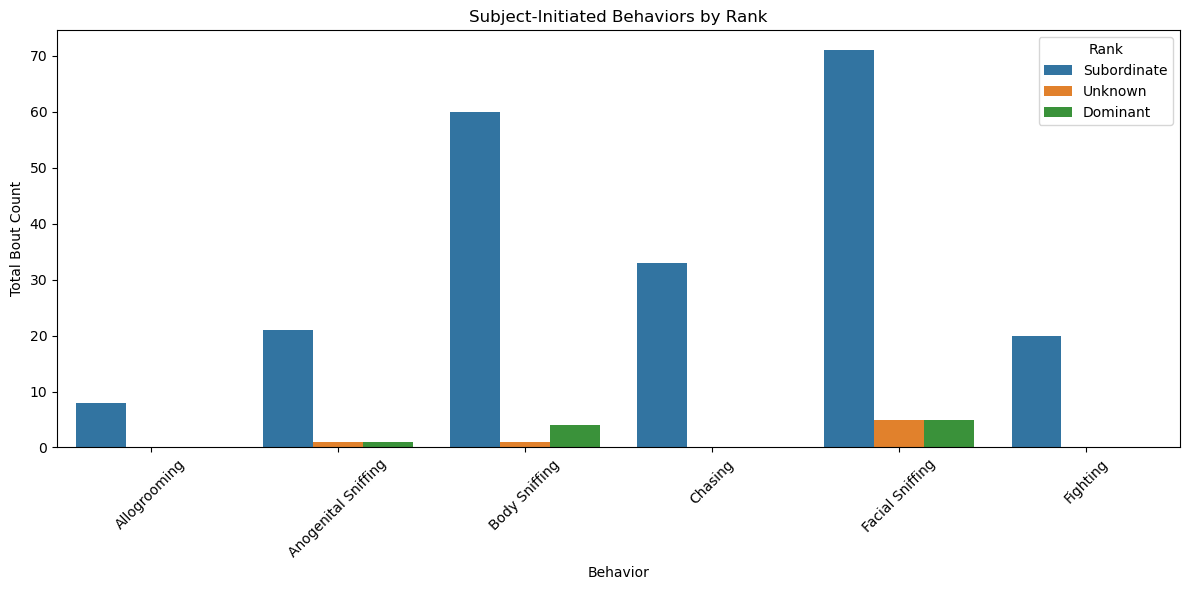

C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3731122592.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


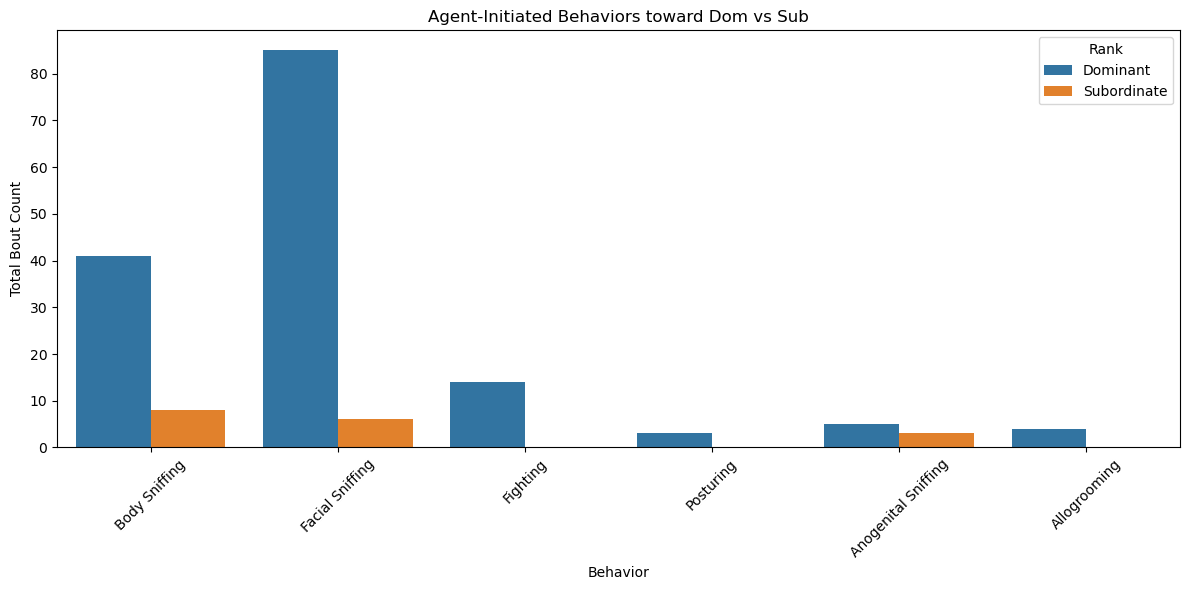

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Subject-initiated behaviors (split by subject's rank) ---
subj_bouts = filtered_bout_counts[
    filtered_bout_counts["Subject"].str.contains("subject", case=False)
]

plt.figure(figsize=(12,6))
sns.barplot(
    data=subj_bouts,
    x="Behavior", y="Bout_Count",
    hue="Rank", estimator=sum, ci=None
)
plt.title("Subject-Initiated Behaviors by Rank")
plt.ylabel("Total Bout Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# --- Agent-initiated behaviors (split by subject's rank, i.e. who the agent is acting on) ---
agent_bouts = filtered_bout_counts[
    filtered_bout_counts["Subject"].str.contains("agent", case=False)
]

plt.figure(figsize=(12,6))
sns.barplot(
    data=agent_bouts,
    x="Behavior", y="Bout_Count",
    hue="Rank", estimator=sum, ci=None
)
plt.title("Agent-Initiated Behaviors toward Dom vs Sub")
plt.ylabel("Total Bout Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
unknown_rank = combined_bouts[combined_bouts["Rank"] == "Unknown"]["Observation id"].unique()
print("⚠️ Files with Unknown rank:")
for obs in unknown_rank:
    print(obs)


⚠️ Files with Unknown rank:
CM_s1_2_sub1_1_20250623_1339321.1


✅ Investigation time summary ready: (37, 6)
  Subject_ID Condition       Subject         Behavior         Rank  Total_Time
0        1_1  Baseline  Social Agent    Body Sniffing     Dominant       1.733
1        1_1  Baseline  Social Agent  Facial Sniffing     Dominant       5.499
2        1_1  Baseline  Social Agent         Fighting     Dominant      15.833
3        1_1  Baseline  Social Agent        Posturing     Dominant       1.200
4        1_1  Baseline       Subject     Allogrooming  Subordinate      12.800


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\1848077561.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


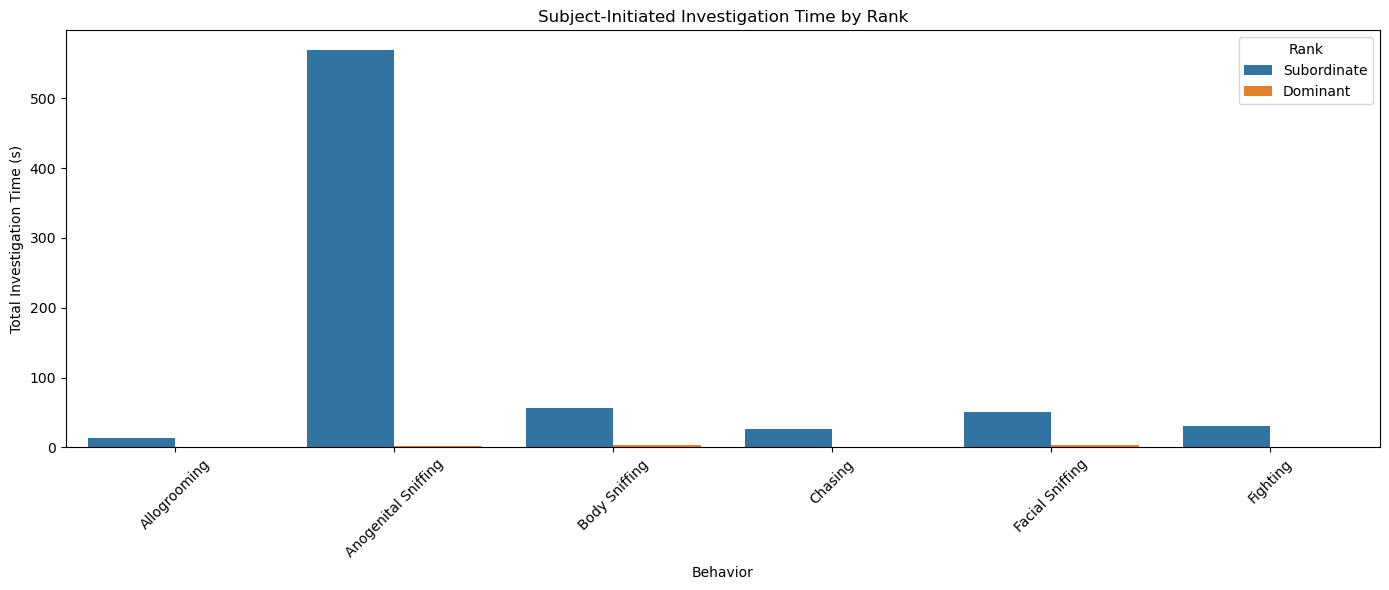

C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\1848077561.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


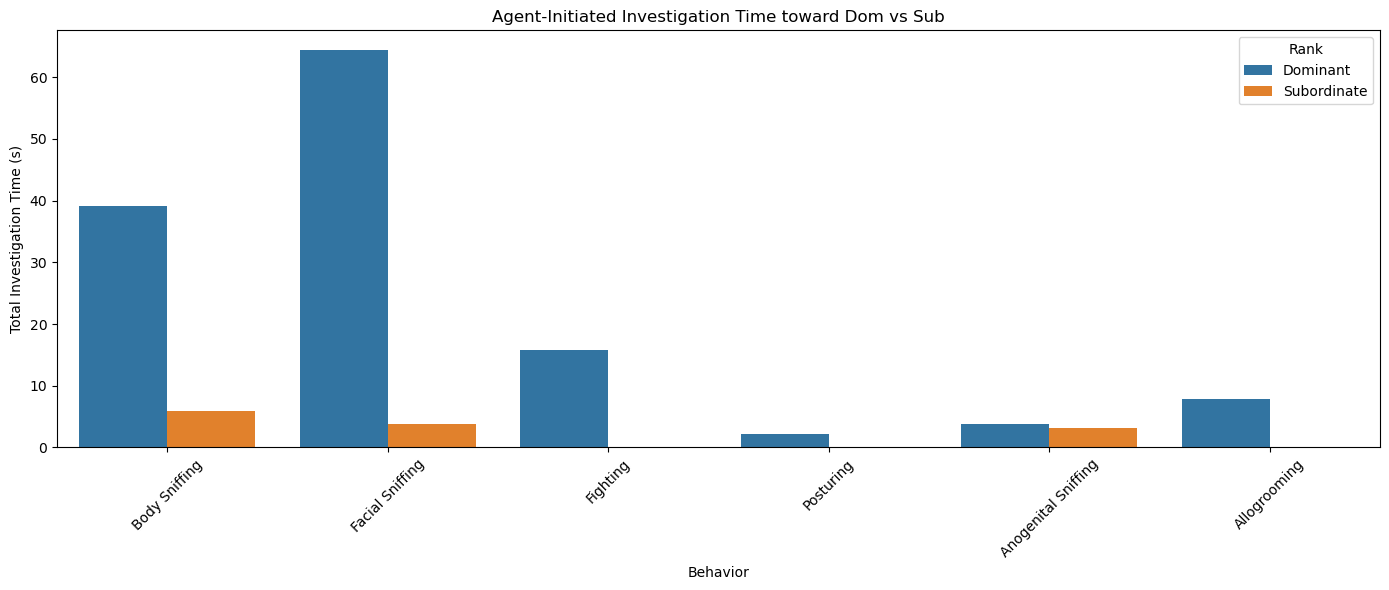

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop bouts without rank info ---
clean_bouts_ranked = combined_bouts[
    combined_bouts["Rank"].isin(["Dominant", "Subordinate"])
].copy()

# --- Compute total investigation time per group ---
time_summary = (
    clean_bouts_ranked
    .groupby(["Subject_ID", "Condition", "Subject", "Behavior", "Rank"])["Duration (s)"]
    .sum()
    .reset_index(name="Total_Time")
)

print("✅ Investigation time summary ready:", time_summary.shape)
print(time_summary.head())

# --- Subject-initiated behaviors ---
subj_times = time_summary[time_summary["Subject"] == "Subject"]

plt.figure(figsize=(14,6))
sns.barplot(
    data=subj_times,
    x="Behavior", y="Total_Time",
    hue="Rank", estimator=sum, ci=None
)
plt.title("Subject-Initiated Investigation Time by Rank")
plt.ylabel("Total Investigation Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Agent-initiated behaviors ---
agent_times = time_summary[time_summary["Subject"] == "Social Agent"]

plt.figure(figsize=(14,6))
sns.barplot(
    data=agent_times,
    x="Behavior", y="Total_Time",
    hue="Rank", estimator=sum, ci=None
)
plt.title("Agent-Initiated Investigation Time toward Dom vs Sub")
plt.ylabel("Total Investigation Time (s)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


✅ Investigation time summary ready: (37, 6)
['Body Sniffing' 'Facial Sniffing' 'Fighting' 'Posturing' 'Allogrooming'
 'Anogenital Sniffing' 'Chasing']


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\2846174144.py:29: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:.25'` for the same effect.

  sns.swarmplot(


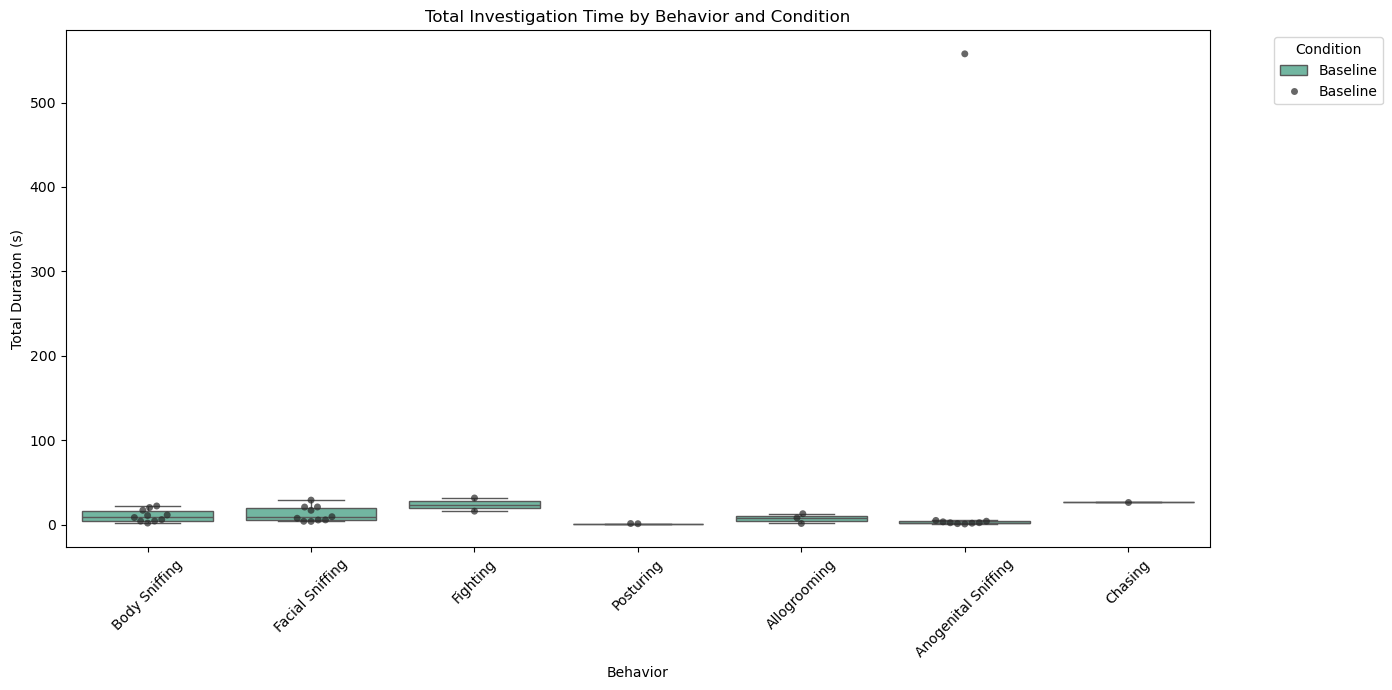

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop unknown rank ---
clean_bouts_ranked = combined_bouts[
    combined_bouts["Rank"].isin(["Dominant", "Subordinate"])
].copy()

# --- Aggregate total duration per bout ---
time_summary = (
    clean_bouts_ranked
    .groupby(["Subject_ID", "Condition", "Subject", "Behavior", "Rank"])["Duration (s)"]
    .sum()
    .reset_index(name="Total_Duration")
)

print("✅ Investigation time summary ready:", time_summary.shape)
print(time_summary["Behavior"].unique())

# --- Boxplot with swarm overlay, all behaviors ---
plt.figure(figsize=(14,7))
sns.boxplot(
    data=time_summary,
    x="Behavior", y="Total_Duration",
    hue="Condition",
    fliersize=0,  # hide outliers (swarmplot shows them)
    palette="Set2"
)
sns.swarmplot(
    data=time_summary,
    x="Behavior", y="Total_Duration",
    hue="Condition",
    dodge=True, color=".25", alpha=0.7
)

plt.title("Total Investigation Time by Behavior and Condition")
plt.ylabel("Total Duration (s)")
plt.xticks(rotation=45)
plt.legend(title="Condition", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Drop bouts longer than 30 seconds ---
filtered_bouts = combined_bouts[combined_bouts["Duration (s)"] <= 30].copy()

# Keep only ranked bouts (drop Unknown)
ranked_bouts = filtered_bouts[filtered_bouts["Rank"].isin(["Dominant", "Subordinate"])].copy()

# --- Map behaviors to new labels ---
behavior_map = {
    "Facial Sniffing": "Face Investigation",
    "Body Sniffing": "Body Investigation",
    "Anogenital Sniffing": "Anogenital Investigation"
}
ranked_bouts["Behavior"] = ranked_bouts["Behavior"].map(behavior_map)

# --- Keep only investigation behaviors ---
investigation_bouts = ranked_bouts[ranked_bouts["Behavior"].notna()]

# --- Aggregate total investigation duration ---
agg_durations = (
    investigation_bouts.groupby(["Subject_ID", "Behavior", "Rank", "InitiatorRole"], as_index=False)
    ["Duration (s)"].sum()
    .rename(columns={"Duration (s)": "Total_Duration"})
)

# --- Split by who initiated ---
subj_initiated = agg_durations[agg_durations["InitiatorRole"] == "Resident"].copy()
agent_initiated = agg_durations[agg_durations["InitiatorRole"] == "Social Agent"].copy()

# --- Map Rank → Valence palette ---
rank_palette = {
    "Subordinate": custom_palette["Positive"],  # Juvenile-like, positive
    "Dominant": custom_palette["Negative"]      # Bully-like, negative
}

# --- Set behavior order ---
behavior_order = ["Face Investigation", "Body Investigation", "Anogenital Investigation"]

# --- Plot side by side ---
fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# Subject-initiated
sns.boxplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[0]
)
sns.stripplot(
    data=subj_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[0]
)
axes[0].set_title("Investigations Initiated by Resident (Subject)")
axes[0].set_ylabel("Total Investigation Time (s)")
axes[0].tick_params(axis='x', rotation=20)

# Agent-initiated
sns.boxplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    palette=rank_palette, fliersize=0, order=behavior_order, ax=axes[1]
)
sns.stripplot(
    data=agent_initiated, x="Behavior", y="Total_Duration", hue="Rank",
    dodge=True, jitter=True, marker="o", alpha=0.9, size=5,
    edgecolor="black", linewidth=0.6, order=behavior_order,
    palette=rank_palette, ax=axes[1]
)
axes[1].set_title("Investigations Initiated by Cage-mate (Social Agent)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=20)

# --- Fix duplicate legends ---
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend_.remove()
fig.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 0.95), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


KeyError: 'InitiatorRole'

In [ ]:
print(
    investigation_bouts[["Trial", "InitiatorRole", "Subject_ID", "Rank"]]
    .drop_duplicates()
    .sort_values("Trial")
    .head(20)
)


             Trial InitiatorRole Subject_ID         Rank
0      CM_1_1_d1_2  Social Agent        1_1     Dominant
1      CM_1_1_d1_2      Resident        1_1  Subordinate
129  CM_1_2_sub1_1  Social Agent        1_2  Subordinate
132  CM_1_2_sub1_1      Resident        1_2     Dominant
163    CM_2_3_d2_4  Social Agent        2_3     Dominant
164    CM_2_3_d2_4      Resident        2_3  Subordinate
260    CM_3_5_d3_6      Resident        3_5  Subordinate
261    CM_3_5_d3_6  Social Agent        3_5     Dominant
350    CM_4_7_d4_8      Resident        4_7  Subordinate
352    CM_4_7_d4_8  Social Agent        4_7     Dominant


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

def compute_resp_rate(signal, fs=100):
    # Find inhalation peaks (you may need to invert if exhalations are peaks)
    min_distance = int(fs * 0.0833)  # ~12 Hz upper limit
    peaks, _ = find_peaks(signal, distance=min_distance)

    # Convert to instantaneous breathing rate (Hz)
    ibi = np.diff(peaks) / fs  # inter-breath interval in seconds
    rate = 1 / ibi

    # Assign times between peaks
    times = (peaks[:-1] + np.diff(peaks) / 2) / fs
    return times, rate


In [ ]:
resp_rates = {}

for label, data in resp_data.items():
    signal, time, fs = data["signal"], data["time"], data["sampling_rate"]

    t_rate, hz_rate = compute_resp_rate(signal, fs)
    resp_rates[label] = pd.DataFrame({
        "Time (s)": t_rate,
        "Respiration Rate (Hz)": hz_rate,
        "Trial": label
    })

# Combine all into one DataFrame
resp_rate_df = pd.concat(resp_rates.values(), ignore_index=True)
print("✅ Respiration rate data:", resp_rate_df.shape)


✅ Respiration rate data: (32846, 3)


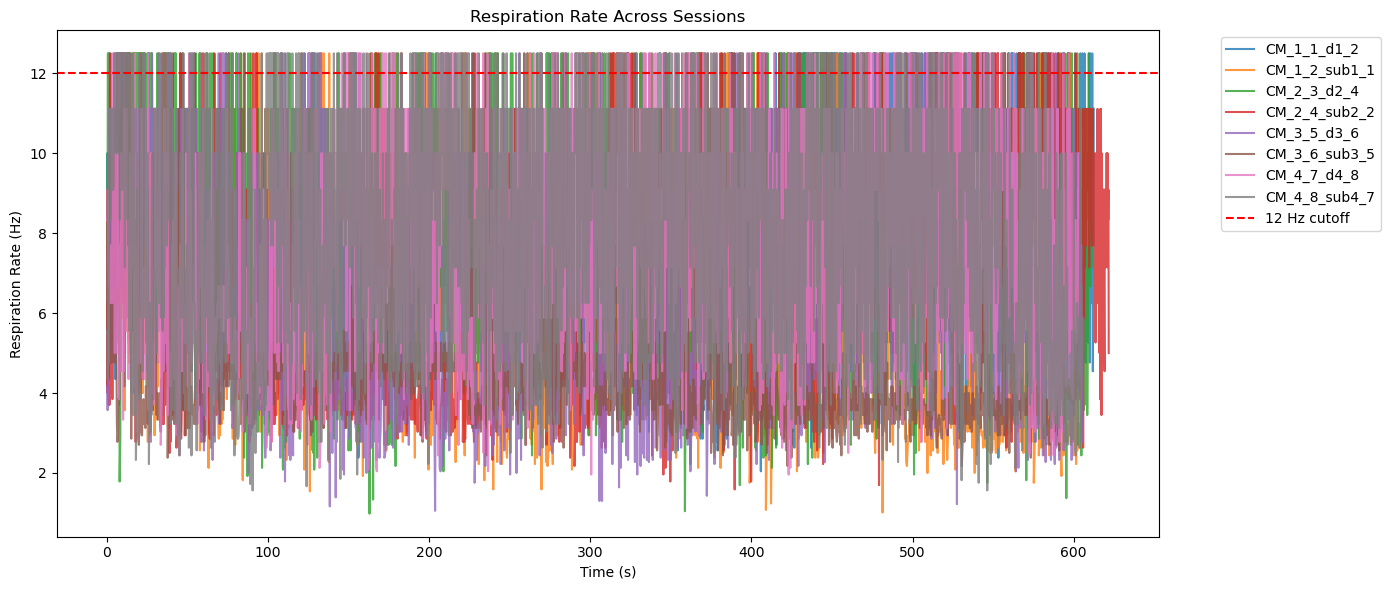

In [ ]:
plt.figure(figsize=(14,6))
for label, df in resp_rates.items():
    plt.plot(df["Time (s)"], df["Respiration Rate (Hz)"], alpha=0.8, label=label)

plt.axhline(12, color="red", linestyle="--", label="12 Hz cutoff")
plt.xlabel("Time (s)")
plt.ylabel("Respiration Rate (Hz)")
plt.title("Respiration Rate Across Sessions")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


✅ Subjects included per condition:
Condition
Baseline    [1_1, 1_2, 2_3, 2_4, 3_5, 3_6, 4_7, 4_8]
Name: Subject_ID, dtype: object


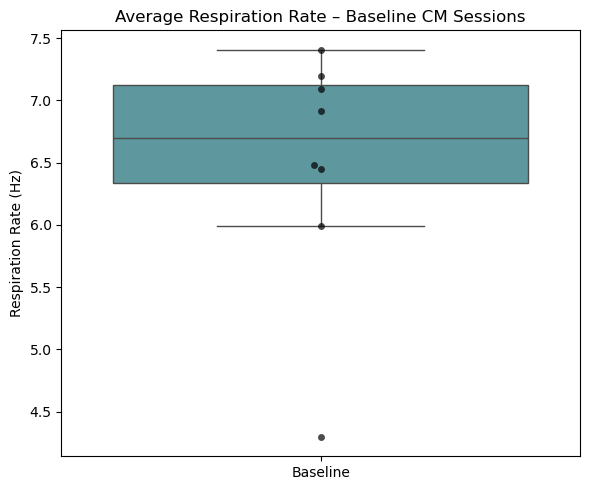

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks
import numpy as np

# --- Respiration rate function ---
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute average breathing rate (Hz) within a time window.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan
    return rate


# --- Collect baseline session rates ---
cm_session_rates = []

for trial, entry in resp_data.items():
    # only keep Baseline CM trials
    if not trial.startswith("CM"):
        continue

    signal = entry['signal']
    time = entry['time']
    sampling_rate = entry['sampling_rate']

    sniff_start = time[0]
    sniff_end = time[-1]

    # compute respiration rate
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate)

    # assign condition
    condition = "Baseline"

    # extract subject ID (CM_1_1_d1_2 → 1_1)
    parts = trial.split("_")
    if len(parts) >= 3:
        subject = f"{parts[1]}_{parts[2]}"
    else:
        subject = "Unknown"

    cm_session_rates.append({
        "Trial": trial,
        "Condition": condition,
        "Subject_ID": subject,
        "Respiration Rate (Hz)": rate
    })

# --- Convert to DataFrame ---
cm_session_df = pd.DataFrame(cm_session_rates)

# --- Debug: check subjects per condition ---
print("✅ Subjects included per condition:")
print(cm_session_df.groupby("Condition")["Subject_ID"].unique())

# --- Plot ---
plt.figure(figsize=(6,5))
sns.boxplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    color=(83/255, 161/255, 169/255), fliersize=0
)
sns.swarmplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    color="black", alpha=0.7
)

plt.title("Average Respiration Rate – Baseline CM Sessions")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")
plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\3015283865.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


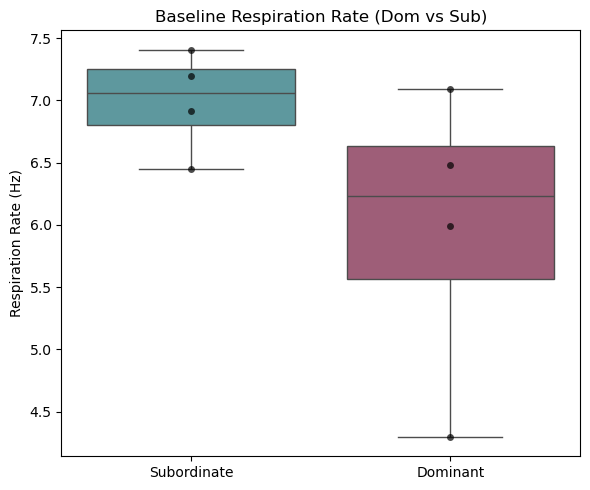

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Make sure Rank is assigned ---
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant"
}
cm_session_df["Rank"] = cm_session_df["Subject_ID"].map(rank_fix)

# --- Only keep Baseline for now ---
baseline_df = cm_session_df[cm_session_df["Condition"] == "Baseline"].copy()

# --- Plot baseline Dom vs Sub ---
plt.figure(figsize=(6,5))
sns.boxplot(
    data=baseline_df, x="Rank", y="Respiration Rate (Hz)",
    palette={
        "Dominant": (169/255, 83/255, 118/255),   # magenta = negative
        "Subordinate": (83/255, 161/255, 169/255) # teal = positive
    },
    fliersize=0
)
sns.swarmplot(
    data=baseline_df, x="Rank", y="Respiration Rate (Hz)",
    color="black", alpha=0.7
)

plt.title("Baseline Respiration Rate (Dom vs Sub)")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")
plt.tight_layout()
plt.show()


In [ ]:
baseline_df


,Trial,Condition,Subject_ID,Respiration Rate (Hz),Rank
0,CM_1_1_d1_2,Baseline,1_1,6.916309,Subordinate
1,CM_1_2_sub1_1,Baseline,1_2,5.990258,Dominant
2,CM_2_3_d2_4,Baseline,2_3,7.407347,Subordinate
3,CM_2_4_sub2_2,Baseline,2_4,6.478013,Dominant
4,CM_3_5_d3_6,Baseline,3_5,6.449590,Subordinate
5,CM_3_6_sub3_5,Baseline,3_6,4.296235,Dominant
6,CM_4_7_d4_8,Baseline,4_7,7.198515,Subordinate
7,CM_4_8_sub4_7,Baseline,4_8,7.095047,Dominant


In [ ]:
baseline_df


,Trial,Condition,Subject_ID,Respiration Rate (Hz),Rank
0,CM_1_1_d1_2,Baseline,1_1,6.916309,Subordinate
1,CM_1_2_sub1_1,Baseline,1_2,5.990258,Dominant
2,CM_2_3_d2_4,Baseline,2_3,7.407347,Subordinate
3,CM_2_4_sub2_2,Baseline,2_4,6.478013,Dominant
4,CM_3_5_d3_6,Baseline,3_5,6.449590,Subordinate
5,CM_3_6_sub3_5,Baseline,3_6,4.296235,Dominant
6,CM_4_7_d4_8,Baseline,4_7,7.198515,Subordinate
7,CM_4_8_sub4_7,Baseline,4_8,7.095047,Dominant


✅ Example rows:
           Trial Condition Subject_ID  Respiration Rate (Hz)
0    CM_1_1_d1_2  Baseline        1_1               6.916309
1  CM_1_2_sub1_1  Baseline        1_2               5.990258
2    CM_2_3_d2_4  Baseline        2_3               7.407347
3  CM_2_4_sub2_2  Baseline        2_4               6.478013
4    CM_3_5_d3_6  Baseline        3_5               6.449590


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\1759654497.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


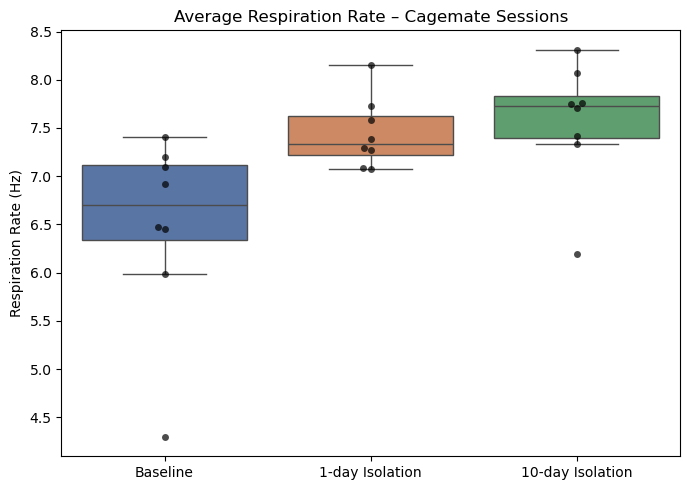

In [ ]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute average breathing rate (Hz) within a time window.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan
    return rate

# --- Loop through all CM trials ---
cm_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    fs = entry['sampling_rate']

    # Whole-session window
    sniff_start = time[0]
    sniff_end = time[-1]

    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=fs)

    # --- Assign condition ---
    if trial.endswith("_1d"):   # 1-day isolation
        condition = "1-day Isolation"
    elif trial.endswith("_10d"):  # (future) 10-day isolation
        condition = "10-day Isolation"
    else:                       # no suffix → baseline
        condition = "Baseline"

    # --- Parse Subject_ID ---
    try:
        parts = trial.split("_")
        subject_id = parts[1] + "_" + parts[2]
    except IndexError:
        subject_id = "Unknown"

    cm_session_rates.append({
        "Trial": trial,
        "Condition": condition,
        "Subject_ID": subject_id,
        "Respiration Rate (Hz)": rate
    })

# Convert to DataFrame
cm_session_df = pd.DataFrame(cm_session_rates)

print("✅ Example rows:")
print(cm_session_df.head())

# --- Plot grouped by condition ---
plt.figure(figsize=(7,5))
sns.boxplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    palette={"Baseline": "#4c72b0", "1-day Isolation": "#dd8452", "10-day Isolation": "#55a868"},
    fliersize=0
)
sns.swarmplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    color="black", alpha=0.7
)

plt.title("Average Respiration Rate – Cagemate Sessions")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")
plt.tight_layout()
plt.show()


✅ Counts per condition × rank:
Condition         Rank       
1-day Isolation   Dominant       4
                  Subordinate    4
10-day Isolation  Dominant       4
                  Subordinate    4
Baseline          Dominant       4
                  Subordinate    4
Name: Subject_ID, dtype: int64


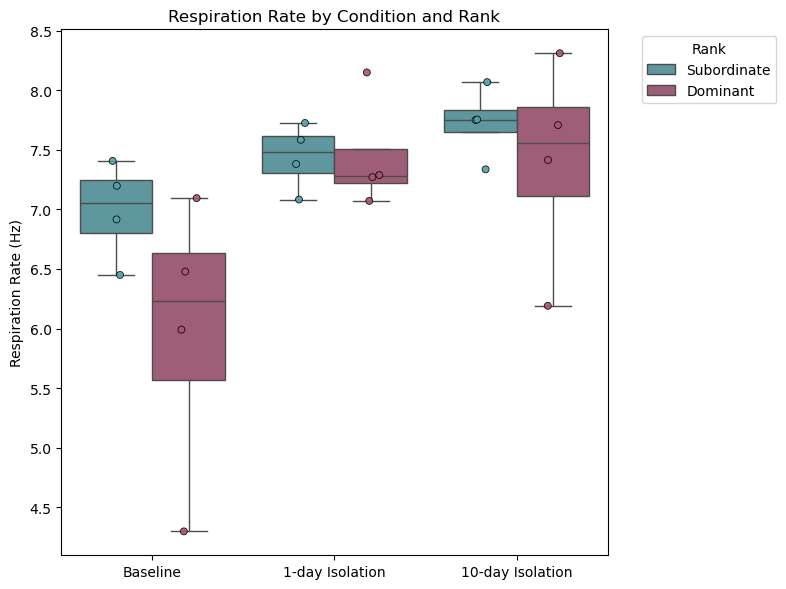

In [ ]:
from scipy.signal import find_peaks
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute average breathing rate (Hz) within a time window.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)  # ≥12 Hz refractory
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan
    return rate

# --- Permanent subject → rank mapping ---
rank_fix = {
    "1_1": "Subordinate", "1_2": "Dominant",
    "2_3": "Subordinate", "2_4": "Dominant",
    "3_5": "Subordinate", "3_6": "Dominant",
    "4_7": "Subordinate", "4_8": "Dominant",
}

# --- Loop through all CM trials ---
cm_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    fs = entry['sampling_rate']

    # Whole-session window
    sniff_start = time[0]
    sniff_end = time[-1]

    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=fs)

    # --- Assign condition ---
    if trial.endswith("_1d"):   # 1-day isolation
        condition = "1-day Isolation"
    elif trial.endswith("_10d"):  # (future) 10-day isolation
        condition = "10-day Isolation"
    else:                       # no suffix → baseline
        condition = "Baseline"

    # --- Parse Subject_ID ---
    try:
        parts = trial.split("_")
        subject_id = parts[1] + "_" + parts[2]
    except IndexError:
        subject_id = "Unknown"

    # --- Map to Rank ---
    rank = rank_fix.get(subject_id, "Unknown")

    cm_session_rates.append({
        "Trial": trial,
        "Condition": condition,
        "Subject_ID": subject_id,
        "Rank": rank,
        "Respiration Rate (Hz)": rate
    })

# Convert to DataFrame
cm_session_df = pd.DataFrame(cm_session_rates)

print("✅ Counts per condition × rank:")
print(cm_session_df.groupby(["Condition", "Rank"])["Subject_ID"].nunique())

# --- Plot grouped by condition × rank ---
plt.figure(figsize=(8,6))
sns.boxplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    hue="Rank", palette={"Dominant": (169/255, 83/255, 118/255),   # magenta
                         "Subordinate": (83/255, 161/255, 169/255)}, # teal
    fliersize=0
)
sns.stripplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    hue="Rank", dodge=True, jitter=True, marker="o",
    alpha=0.9, size=5, edgecolor="black", linewidth=0.6,
    palette={"Dominant": (169/255, 83/255, 118/255),
             "Subordinate": (83/255, 161/255, 169/255)}
)

plt.title("Respiration Rate by Condition and Rank")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")

# Fix duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], bbox_to_anchor=(1.05, 1), loc='upper left', title="Rank")

plt.tight_layout()
plt.show()


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\1053736355.py:22: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


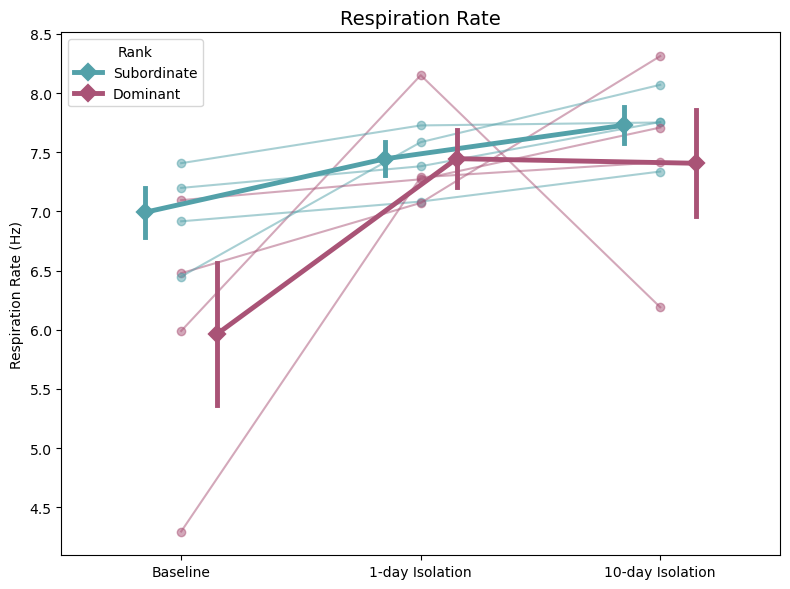

In [326]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

# --- Subject-level trajectories (no legend entries) ---
for _, row in paired_df.iterrows():
    plt.plot(
        ["Baseline", "1-day Isolation", "10-day Isolation"],
        [row["Baseline"], row["1-day Isolation"], row["10-day Isolation"]],
        marker="o", linestyle="-", alpha=0.5,
        color=(169/255, 83/255, 118/255) if row["Rank"]=="Dominant" else (83/255, 161/255, 169/255),
    )

# --- Overlay group mean ± SEM ---
long_df = paired_df.melt(
    id_vars=["Subject_ID", "Rank"],
    value_vars=["Baseline", "1-day Isolation", "10-day Isolation"],
    var_name="Condition", value_name="Respiration Rate (Hz)"
)

sns.pointplot(
    data=long_df, x="Condition", y="Respiration Rate (Hz)", hue="Rank",
    errorbar="se", markers="D", scale=1.3, dodge=0.3,
    palette={"Dominant": (169/255, 83/255, 118/255),
             "Subordinate": (83/255, 161/255, 169/255)}
)

# --- Final formatting ---
plt.title("Respiration Rate", fontsize=14)
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")


plt.tight_layout()
plt.show()


In [327]:
from scipy.stats import friedmanchisquare, wilcoxon
import pandas as pd
import numpy as np

# --- Prepare results storage ---
results = []

# --- Loop through ranks separately ---
for rank in paired_df["Rank"].unique():
    subdf = paired_df[paired_df["Rank"] == rank].dropna(subset=["Baseline", "1-day Isolation", "10-day Isolation"])
    
    if subdf.empty:
        continue

    # Friedman test (3 conditions within-subject)
    stat, p = friedmanchisquare(subdf["Baseline"], subdf["1-day Isolation"], subdf["10-day Isolation"])
    results.append({
        "Rank": rank,
        "Test": "Friedman",
        "Comparison": "Baseline vs 1d vs 10d",
        "Statistic": stat,
        "p-value": p
    })

    # Pairwise Wilcoxon (nonparametric, paired)
    pairs = [
        ("Baseline", "1-day Isolation"),
        ("Baseline", "10-day Isolation"),
        ("1-day Isolation", "10-day Isolation")
    ]
    
    for cond1, cond2 in pairs:
        try:
            stat, p = wilcoxon(subdf[cond1], subdf[cond2])
            results.append({
                "Rank": rank,
                "Test": "Wilcoxon",
                "Comparison": f"{cond1} vs {cond2}",
                "Statistic": stat,
                "p-value": p
            })
        except ValueError:
            # Wilcoxon fails if all differences are 0
            results.append({
                "Rank": rank,
                "Test": "Wilcoxon",
                "Comparison": f"{cond1} vs {cond2}",
                "Statistic": np.nan,
                "p-value": np.nan
            })

# --- Convert to DataFrame ---
stats_df = pd.DataFrame(results)

print("✅ Statistical Results:")
print(stats_df)


✅ Statistical Results:
          Rank      Test                           Comparison  Statistic   p-value
0  Subordinate  Friedman                Baseline vs 1d vs 10d        8.0  0.018316
1  Subordinate  Wilcoxon          Baseline vs 1-day Isolation        0.0  0.125000
2  Subordinate  Wilcoxon         Baseline vs 10-day Isolation        0.0  0.125000
3  Subordinate  Wilcoxon  1-day Isolation vs 10-day Isolation        0.0  0.125000
4     Dominant  Friedman                Baseline vs 1d vs 10d        6.5  0.038774
5     Dominant  Wilcoxon          Baseline vs 1-day Isolation        0.0  0.125000
6     Dominant  Wilcoxon         Baseline vs 10-day Isolation        0.0  0.125000
7     Dominant  Wilcoxon  1-day Isolation vs 10-day Isolation        4.0  0.875000


In [329]:
from scipy.stats import friedmanchisquare, wilcoxon

results = []

for rank in ["Subordinate", "Dominant"]:
    rank_df = cm_session_df[cm_session_df["Rank"] == rank]

    # Pivot so each subject has Baseline, 1-day, 10-day side by side
    wide = rank_df.pivot(index="Subject_ID", columns="Condition", values="Respiration Rate (Hz)")

    # --- Friedman test (repeated measures across conditions)
    if all(col in wide.columns for col in ["Baseline", "1-day Isolation", "10-day Isolation"]):
        stat, p = friedmanchisquare(wide["Baseline"], wide["1-day Isolation"], wide["10-day Isolation"])
        results.append({
            "Rank": rank,
            "Test": "Friedman (Baseline vs 1d vs 10d)",
            "Statistic": stat,
            "p-value": p,
            "n": len(wide)
        })

    # --- Pairwise Wilcoxon
    comparisons = [
        ("Baseline", "1-day Isolation"),
        ("Baseline", "10-day Isolation"),
        ("1-day Isolation", "10-day Isolation")
    ]
    for c1, c2 in comparisons:
        if c1 in wide.columns and c2 in wide.columns:
            paired = wide[[c1, c2]].dropna()
            if len(paired) > 0:
                stat, p = wilcoxon(paired[c1], paired[c2])
                results.append({
                    "Rank": rank,
                    "Test": "Wilcoxon",
                    "Comparison": f"{c1} vs {c2}",
                    "Statistic": stat,
                    "p-value": p,
                    "n": len(paired)
                })

results_df = pd.DataFrame(results)
print("✅ Isolation condition stats within each rank:")
print(results_df)


✅ Isolation condition stats within each rank:
          Rank                              Test  Statistic   p-value  n                           Comparison
0  Subordinate  Friedman (Baseline vs 1d vs 10d)        8.0  0.018316  4                                  NaN
1  Subordinate                          Wilcoxon        0.0  0.125000  4          Baseline vs 1-day Isolation
2  Subordinate                          Wilcoxon        0.0  0.125000  4         Baseline vs 10-day Isolation
3  Subordinate                          Wilcoxon        0.0  0.125000  4  1-day Isolation vs 10-day Isolation
4     Dominant  Friedman (Baseline vs 1d vs 10d)        6.5  0.038774  4                                  NaN
5     Dominant                          Wilcoxon        0.0  0.125000  4          Baseline vs 1-day Isolation
6     Dominant                          Wilcoxon        0.0  0.125000  4         Baseline vs 10-day Isolation
7     Dominant                          Wilcoxon        4.0  0.875000  4  

In [330]:
from scipy.stats import friedmanchisquare, wilcoxon

# --- Pivot to wide format (each subject: Baseline, 1-day, 10-day)
wide_all = cm_session_df.pivot(
    index="Subject_ID",
    columns="Condition",
    values="Respiration Rate (Hz)"
)

print("✅ Wide table for all subjects:")
print(wide_all)

results = []

# --- Friedman test across the 3 conditions
if all(c in wide_all.columns for c in ["Baseline", "1-day Isolation", "10-day Isolation"]):
    stat, p = friedmanchisquare(
        wide_all["Baseline"], 
        wide_all["1-day Isolation"], 
        wide_all["10-day Isolation"]
    )
    results.append({
        "Test": "Friedman (Baseline vs 1d vs 10d)",
        "Statistic": stat,
        "p-value": p,
        "n": len(wide_all)
    })

# --- Pairwise Wilcoxon comparisons
comparisons = [
    ("Baseline", "1-day Isolation"),
    ("Baseline", "10-day Isolation"),
    ("1-day Isolation", "10-day Isolation")
]
for c1, c2 in comparisons:
    if c1 in wide_all.columns and c2 in wide_all.columns:
        paired = wide_all[[c1, c2]].dropna()
        if len(paired) > 0:
            stat, p = wilcoxon(paired[c1], paired[c2])
            results.append({
                "Test": "Wilcoxon",
                "Comparison": f"{c1} vs {c2}",
                "Statistic": stat,
                "p-value": p,
                "n": len(paired)
            })

results_df = pd.DataFrame(results)
print("\n✅ Isolation condition stats (all 8 mice together):")
print(results_df)


✅ Wide table for all subjects:
Condition   1-day Isolation  10-day Isolation  Baseline
Subject_ID                                             
1_1                7.083084          7.336893  6.916309
1_2                8.150445          6.190539  5.990258
2_3                7.726170          7.751133  7.407347
2_4                7.071799          8.311774  6.478013
3_5                7.584788          8.069322  6.449590
3_6                7.288331          7.415212  4.296235
4_7                7.381238          7.754960  7.198515
4_8                7.271189          7.708510  7.095047

✅ Isolation condition stats (all 8 mice together):
                               Test  Statistic   p-value  n                           Comparison
0  Friedman (Baseline vs 1d vs 10d)      14.25  0.000805  8                                  NaN
1                          Wilcoxon       0.00  0.007812  8          Baseline vs 1-day Isolation
2                          Wilcoxon       0.00  0.007812  8       

In [321]:
# --- Pivot to wide format for paired plotting ---
paired_df = cm_session_df.pivot_table(
    index=["Subject_ID", "Rank"],
    columns="Condition",
    values="Respiration Rate (Hz)"
).reset_index()

print("✅ Pivoted columns:", paired_df.columns.tolist())

# Try to print subset (adjust column names if needed)
cols_to_show = ["Subject_ID", "Rank"]
for cond in ["Baseline", "1-day Iso", "10-day Iso"]:
    if cond in paired_df.columns:
        cols_to_show.append(cond)

print("\n✅ Paired table (Baseline → 1-day Iso → 10-day Iso):")
print(paired_df[cols_to_show])


✅ Pivoted columns: ['Subject_ID', 'Rank', '1-day Isolation', '10-day Isolation', 'Baseline']

✅ Paired table (Baseline → 1-day Iso → 10-day Iso):
Condition Subject_ID         Rank  Baseline
0                1_1  Subordinate  6.916309
1                1_2     Dominant  5.990258
2                2_3  Subordinate  7.407347
3                2_4     Dominant  6.478013
4                3_5  Subordinate  6.449590
5                3_6     Dominant  4.296235
6                4_7  Subordinate  7.198515
7                4_8     Dominant  7.095047


✅ Paired table (Baseline → 1-day → 10-day):
Condition SubjectID         Rank  Baseline  1-day Isolation  10-day Isolation
0               1_1  Subordinate  6.916309         7.083084          7.336893
1               1_2     Dominant  5.990258         8.150445          6.190539
2               2_3  Subordinate  7.407347         7.726170          7.751133
3               2_4     Dominant  6.478013         7.071799          8.311774
4               3_5  Subordinate  6.449590         7.584788          8.069322
5               3_6     Dominant  4.296235         7.288331          7.415212
6               4_7  Subordinate  7.198515         7.381238          7.754960
7               4_8     Dominant  7.095047         7.271189          7.708510


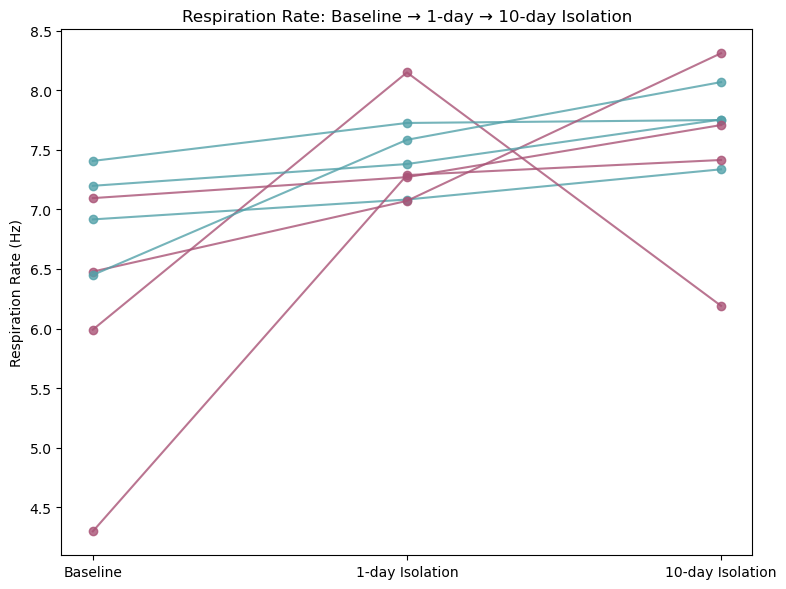

In [ ]:
# --- Fix condition names ---
condition_map = {
    "Baseline": "Baseline",
    "1-day Iso": "1-day Isolation",
    "10-day Iso": "10-day Isolation"
}
cm_session_df["Condition"] = cm_session_df["Condition"].map(condition_map)

# --- Pivot to wide format ---
paired_df = cm_session_df.pivot_table(
    index=["SubjectID", "Rank"],
    columns="Condition",
    values="Respiration Rate (Hz)"
).reset_index()

print("✅ Paired table (Baseline → 1-day → 10-day):")
print(paired_df[["SubjectID", "Rank", "Baseline", "1-day Isolation", "10-day Isolation"]])

# --- Plot paired changes ---
plt.figure(figsize=(8,6))

for _, row in paired_df.iterrows():
    plt.plot(
        ["Baseline", "1-day Isolation", "10-day Isolation"],
        [row["Baseline"], row["1-day Isolation"], row["10-day Isolation"]],
        marker="o",
        color=(169/255, 83/255, 118/255) if row["Rank"] == "Dominant" else (83/255, 161/255, 169/255),
        alpha=0.8
    )

plt.title("Respiration Rate: Baseline → 1-day → 10-day Isolation")
plt.ylabel("Respiration Rate (Hz)")
plt.xticks(["Baseline", "1-day Isolation", "10-day Isolation"])
plt.tight_layout()
plt.show()


In [ ]:
print("Unique condition labels in cm_session_df:")
print(cm_session_df["Condition"].unique())


Unique condition labels in cm_session_df:
['Baseline' '1-day Iso' '10-day Iso']


In [ ]:
cm_session_df

,Trial,Condition,Subject_ID,Respiration Rate (Hz)
0,CM_1_1_d1_2,Baseline,1_1,6.916309
1,CM_1_2_sub1_1,Baseline,1_2,5.990258
2,CM_2_3_d2_4,Baseline,2_3,7.407347
3,CM_2_4_sub2_2,Baseline,2_4,6.478013
4,CM_3_5_d3_6,Baseline,3_5,6.449590
5,CM_3_6_sub3_5,Baseline,3_6,4.296235
6,CM_4_7_d4_8,Baseline,4_7,7.198515
7,CM_4_8_sub4_7,Baseline,4_8,7.095047
8,CM_1_1_d1_2_1d,1-day Isolation,1_1,7.083084
9,CM_1_2_sub1_1_1d,1-day Isolation,1_2,8.150445


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks

# --- Function to compute respiration rate ---
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    # Detect peaks with refractory for max ~12 Hz breathing
    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.0833)
    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan
    return rate

# --- Collect results ---
cm_session_rates = []

for trial, entry in resp_data.items():
    signal = entry['signal']
    time = entry['time']
    fs = entry['sampling_rate']

    sniff_start, sniff_end = time[0], time[-1]
    rate = get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=fs)

    # --- Condition ---
    if trial.endswith("_1d"):
        condition = "1-day Iso"
    elif trial.endswith("_10d"):
        condition = "10-day Iso"
    else:
        condition = "Baseline"

    # --- Subject ID (e.g., "CM_1_1_d1_2" → "1_1") ---
    parts = trial.split("_")
    try:
        subj_id = parts[1] + "_" + parts[2]
    except IndexError:
        subj_id = "Unknown"

    cm_session_rates.append({
        "Trial": trial,
        "Condition": condition,
        "SubjectID": subj_id,
        "Respiration Rate (Hz)": rate
    })

# --- Build DataFrame ---
cm_session_df = pd.DataFrame(cm_session_rates)
print("✅ Respiration rates DataFrame ready:", cm_session_df.shape)
print(cm_session_df.head())


✅ Respiration rates DataFrame ready: (24, 4)
           Trial Condition SubjectID  Respiration Rate (Hz)
0    CM_1_1_d1_2  Baseline       1_1               6.916309
1  CM_1_2_sub1_1  Baseline       1_2               5.990258
2    CM_2_3_d2_4  Baseline       2_3               7.407347
3  CM_2_4_sub2_2  Baseline       2_4               6.478013
4    CM_3_5_d3_6  Baseline       3_5               6.449590


C:\Users\sjs93\AppData\Local\Temp\ipykernel_30668\2511430519.py:9: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


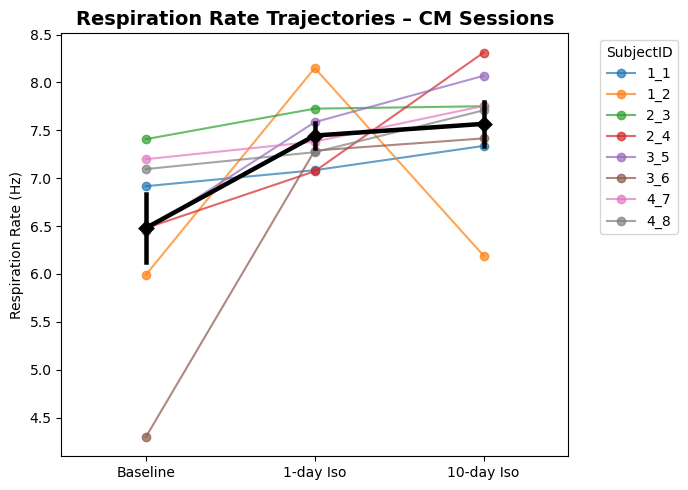

In [ ]:
plt.figure(figsize=(7,5))

# Plot each subject trajectory
for subj, subdf in cm_session_df.groupby("SubjectID"):
    plt.plot(subdf["Condition"], subdf["Respiration Rate (Hz)"],
             marker="o", linestyle="-", alpha=0.7, label=subj)

# Overlay group mean ± SEM
sns.pointplot(
    data=cm_session_df, x="Condition", y="Respiration Rate (Hz)",
    color="black", errorbar="se", markers="D", scale=1.2
)

plt.title("Respiration Rate Trajectories – CM Sessions", fontsize=14, weight="bold")
plt.ylabel("Respiration Rate (Hz)")
plt.xlabel("")
plt.legend(title="SubjectID", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()



In [ ]:
print("✅ Subjects per condition:")
print(cm_session_df.groupby("Condition")["SubjectID"].unique())


✅ Subjects per condition:
Condition
1-day Iso     [1_1, 1_2, 2_3, 2_4, 3_5, 3_6, 4_7, 4_8]
10-day Iso    [1_1, 1_2, 2_3, 2_4, 3_5, 3_6, 4_7, 4_8]
Baseline      [1_1, 1_2, 2_3, 2_4, 3_5, 3_6, 4_7, 4_8]
Name: SubjectID, dtype: object
